# Problem & Objective
## Problem
- This challenge provides a rich dataset capturing the financial behaviour, resilience, and operational realities of small and medium-sized enterprises (SMEs) across Eswatini, Lesotho, Malawi, and Zimbabwe. The data is sourced from SME surveys and includes detailed information about business owners, their financial habits, exposure to risks, access to credit, and overall business performance.

## Objective
- Your task is to use these features to predict the Financial Health Index (FHI) - a category of low, medium or high that reflects how financially resilient and well-positioned each business is. The index incorporates aspects such as savings habits, debt, shock resilience, and access to formal financial services.

### Points
- This is a classification problem. Categories are
    - High
    - Medium
    - Low
- The target variable is the FHI (Financial Health Index)
- The evaluation metric for this challenge is the F1 score (A balance between FP & FN)

# Data Pre-Processing
### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display maximum rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### 2. Data Loading

In [2]:
train_data = pd.read_csv('Train.csv')
test_data = pd.read_csv('Test.csv')
ss= pd.read_csv('SampleSubmission.csv')
variable_definitions = pd.read_csv('VariableDefinitions.csv')

### 3. Overview

In [3]:
train_data.head(20)

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,7000.0,14.0,Never had,Have now,Yes,Yes,Male,"Yes, sometimes",No,Never had,"Yes, always",Yes,Yes,No,Yes,Yes,Yes,Yes,Never had,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,NaN,15.0,Have now,Have now,NaN,Yes,Male,"Yes, sometimes",Yes,Never had,"Yes, always",No,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,13000.0,5.0,NaN,Never had,Yes,Yes,Male,"Yes, sometimes",Yes,Never had,No,Don?t know / doesn?t apply,Yes,No,NaN,Yes,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,30000.0,1.0,NaN,Have now,No,Yes,Female,"Yes, sometimes",No,Never had,No,No,Yes,No,NaN,Yes,No,No,Never had,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,1800.0,3.0,Never had,NaN,NaN,No,Female,"Yes, sometimes",Yes,Never had,No,Yes,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low
5,ID_57I1NI,lesotho,39.0,Yes,No,No,Don't know,Yes,250.0,10.0,60.0,0.0,Never had,Have now,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now,Low
6,ID_L3TKQV,lesotho,25.0,Yes,Yes,No,No,No,10000.0,1350.0,3000.0,7.0,Never had,Have now,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now,Medium
7,ID_KB700U,eswatini,44.0,Yes,Yes,No,Yes,Yes,14000.0,8500.0,15000.0,1.0,Never had,Have now,Yes,Yes,Male,No,No,Never had,"Yes, always",No,Yes,No,Don't know,Yes,Yes,Yes,Never had,Never had,Never had,NaN,0.0,Never had,Never had,NaN,Never had,Never had,Low
8,ID_DUQI8U,zimbabwe,34.0,Yes,No,No,Yes,Yes,150.0,1680.0,3360.0,5.0,Never had,NaN,NaN,Yes,Female,No,Yes,Never had,"Yes, sometimes",Don't know,Do not know / N‎/A,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Have now,Yes,NaN,NaN,Medium
9,ID_27YH6U,eswatini,65.0,Yes,No,Yes,No,No,5000.0,9000.0,22000.0,20.0,Have now,Have now,Yes,Yes,Male,No,No,Never had,"Yes, always",No,Yes,Yes,No,Yes,NaN,Yes,Never had,Never had,Have now,NaN,5.0,Never had,Have now,NaN,Never had,Never had,Medium


In [4]:
test_data.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,7200.0,15.0,Never had,NaN,NaN,Yes,Female,"Yes, sometimes",No,Never had,"Yes, always",No,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,900.0,5.0,Never had,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Don't know,No,Yes,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,1000.0,10.0,Never had,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,Yes,Yes,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,20000.0,4.0,NaN,Have now,No,Yes,Male,"Yes, sometimes",No,Never had,No,Don?t know / doesn?t apply,Yes,No,NaN,No,No,Yes,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,2000.0,1.0,Never had,Have now,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,No,Yes,Yes,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


In [5]:
ss.head()

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


In [6]:
variable_definitions

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [7]:
print("Train data shape: ", train_data.shape)
print("Test data shape: ", test_data.shape)

Train data shape:  (9618, 39)
Test data shape:  (2405, 38)


In [8]:
# Check if test_data has target feature
test_cols = test_data.columns.to_list()

if 'Target' in test_cols:
    print('Test data has the Target feature')
else:
    print('Target feature not in Test data')

Target feature not in Test data


- The test_data does not have Target feature, so data leakage is impossible

In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-null   object 
 7   perception_cannot_afford_insuranc

In [10]:
train_data.describe()

,owner_age,personal_income,business_expenses,business_turnover,business_age_years,business_age_months
count,9618.000000,9.509000e+03,9.389000e+03,9.402000e+03,9366.000000,5507.000000
mean,41.705344,2.627345e+05,4.583838e+05,1.348210e+06,7.030536,3.636281
std,13.314010,2.566268e+06,6.184746e+06,8.804741e+06,7.650349,3.386488
min,18.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,32.000000,3.000000e+02,7.000000e+02,1.500000e+03,2.000000,0.000000
50%,40.000000,2.000000e+03,3.000000e+03,6.000000e+03,4.000000,3.000000
75%,50.000000,2.500000e+04,2.500000e+04,5.000000e+04,10.000000,6.000000
max,103.000000,1.500000e+08,5.000000e+08,4.200000e+08,60.000000,11.000000


- The train_data has 6 numerical columns
- Features:
    - In owner_age max value is 103 and min is 18, but most values range between 32-50: This indicates presence of outliers
    - In business_age_years max value is 60 and min is 0, but most values range between 2-4: Presence of outliers

### 4. Missing values

In [11]:
train_data.isnull().sum()

ID                                                                     0
country                                                                0
owner_age                                                              0
attitude_stable_business_environment                                   2
attitude_worried_shutdown                                              2
compliance_income_tax                                                  4
perception_insurance_doesnt_cover_losses                               5
perception_cannot_afford_insurance                                     5
personal_income                                                      109
business_expenses                                                    229
business_turnover                                                    216
business_age_years                                                   252
motor_vehicle_insurance                                             2244
has_mobile_money                                   

In [12]:
# Identify numerical columns
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Target' in numerical_cols:
    numerical_cols.remove('Target')

# Identify categorical columns
categorical_cols = train_data.select_dtypes(include=['object']).columns.tolist()
if 'ID' in categorical_cols:
    categorical_cols.remove('ID')
if 'Target' in categorical_cols:
    categorical_cols.remove('Target')

In [13]:
# check cardinality in categorical columns
for col in categorical_cols:
    print(train_data[col].value_counts())
    print('')

country
eswatini    2674
zimbabwe    2612
malawi      2388
lesotho     1944
Name: count, dtype: int64

attitude_stable_business_environment
Yes                  5820
No                   2451
Don’t know or N/A    1345
Name: count, dtype: int64

attitude_worried_shutdown
No                   5804
Yes                  3575
Don’t know or N/A     237
Name: count, dtype: int64

compliance_income_tax
No            8010
Yes           1252
Don’t know     341
Refused         11
Name: count, dtype: int64

perception_insurance_doesnt_cover_losses
No            4486
Yes           2604
Don't know    2523
Name: count, dtype: int64

perception_cannot_afford_insurance
Yes           6056
No            2093
Don't know    1464
Name: count, dtype: int64

motor_vehicle_insurance
Never had                          6994
Have now                            297
Used to have but don’t have now      47
Don't know                           36
Name: count, dtype: int64

has_mobile_money
Have now                   

In [14]:
def clean_categorical_data(df):
    """
    Clean all categorical columns in the dataframe
    """
    # Dictionary of standardized values
    standardization_map = {
        # Don't know variations
        "Don't know": [
            ' Do not know / N‎/A',
            "Don't know or N/A", "Don’t know or N/A", 
            "Don?t know / doesn?t apply", 'Do not know / N‎/A', "Do not know / N/A",
            "Don't know", "Don't Know", "Don't know",
            "Don't know (Do not show)", "Don’t know (Do not show)"
        ],
        
        # Insurance/account status
        "Used to have": [
            "Used to have but don't have now", 
            "Used to have but don’t have now"
        ],
        "Currently have": ["Have now"],
        "Never had": ["Never had"],
        
        # Yes/No variations
        "No": ['0', "No"],
        "Sometimes": ["Yes, sometimes"],
        "Yes": ["Yes", "Yes, always", 'Always']
    }
    
    # Apply standardization
    for standardized, variations in standardization_map.items():
        for variation in variations:
            for col in df.columns:
                df[col] = df[col].replace(variation, standardized)
    
    return df

train_data = clean_categorical_data(train_data)
test_data = clean_categorical_data(test_data)

In [15]:
missing_pct = train_data.isnull().mean().sort_values(ascending=False) * 100
missing_pct

uses_informal_lender                                                46.672905
uses_friends_family_savings                                         46.662508
motivation_make_more_money                                          44.614265
funeral_insurance                                                   43.543356
medical_insurance                                                   43.543356
business_age_months                                                 42.742774
future_risk_theft_stock                                             42.628405
has_debit_card                                                      41.619879
has_internet_banking                                                41.619879
has_loan_account                                                    41.578291
current_problem_cash_flow                                           39.280516
marketing_word_of_mouth                                             38.417550
problem_sourcing_money                                          

In [16]:
train_data[train_data['uses_informal_lender'].isna()].head(10)

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,NaN,15.0,Currently have,Currently have,NaN,Yes,Male,Sometimes,Yes,Never had,Yes,No,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don't know,No,No,Don't know,Yes,30000.0,6000.0,13000.0,5.0,NaN,Never had,Yes,Yes,Male,Sometimes,Yes,Never had,No,Don't know,Yes,No,NaN,Yes,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,1800.0,3.0,Never had,NaN,NaN,No,Female,Sometimes,Yes,Never had,No,Yes,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low
8,ID_DUQI8U,zimbabwe,34.0,Yes,No,No,Yes,Yes,150.0,1680.0,3360.0,5.0,Never had,NaN,NaN,Yes,Female,No,Yes,Never had,Sometimes,Don't know,Don't know,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Currently have,Yes,NaN,NaN,Medium
10,ID_CBJS4T,malawi,42.0,Yes,No,No,Don't know,Yes,1166000.0,7000000.0,14000000.0,10.0,NaN,Currently have,No,No,Female,Sometimes,Yes,Never had,No,Don't know,Yes,No,NaN,Yes,No,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
13,ID_RNUTPC,zimbabwe,41.0,Yes,No,No,No,Yes,200.0,2880.0,5400.0,4.0,Never had,NaN,Yes,No,Male,No,Yes,Never had,Sometimes,No,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,9.0,Used to have,Used to have,NaN,NaN,NaN,Low
15,ID_LCUFVJ,zimbabwe,43.0,No,No,No,No,No,250.0,480.0,1080.0,4.0,Never had,NaN,NaN,Yes,Male,Yes,No,Never had,Sometimes,No,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,Yes,4.0,Never had,Never had,NaN,NaN,NaN,Medium
16,ID_P1KFV4,zimbabwe,32.0,Yes,Yes,Don’t know,No,Yes,350.0,NaN,NaN,6.0,Never had,NaN,NaN,No,Female,Sometimes,Yes,Never had,Sometimes,No,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Never had,NaN,NaN,NaN,Low
17,ID_GMTQ0H,zimbabwe,34.0,Yes,Yes,Don’t know,No,Yes,400.0,1800.0,2400.0,6.0,Currently have,NaN,NaN,Yes,Female,Sometimes,No,Never had,Sometimes,Don't know,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,7.0,Never had,Never had,NaN,NaN,NaN,Medium
20,ID_1AYAQR,malawi,28.0,Don't know,Yes,No,Yes,Yes,80000.0,25000.0,10000.0,12.0,NaN,Never had,No,No,Female,No,No,Never had,No,Yes,Don't know,No,NaN,Don't know,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low


- Almost all entries that have missing values in 'uses_informal_lender' are also missing in 'uses_friends_family_savings', maybe we can have a feature for informal sources of cash, with these two
- Missingness has meaning, it could be owners did not want to reveal theirs sources for their reasons

In [17]:
train_data[train_data['motivation_make_more_money'].notna()].head(15)

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
2,ID_TY93LV,malawi,34.0,Don't know,No,No,Don't know,Yes,30000.0,6000.0,13000.0,5.0,NaN,Never had,Yes,Yes,Male,Sometimes,Yes,Never had,No,Don't know,Yes,No,NaN,Yes,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,30000.0,1.0,NaN,Currently have,No,Yes,Female,Sometimes,No,Never had,No,No,Yes,No,NaN,Yes,No,No,Never had,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Currently have,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,1800.0,3.0,Never had,NaN,NaN,No,Female,Sometimes,Yes,Never had,No,Yes,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low
5,ID_57I1NI,lesotho,39.0,Yes,No,No,Don't know,Yes,250.0,10.0,60.0,0.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Low
6,ID_L3TKQV,lesotho,25.0,Yes,Yes,No,No,No,10000.0,1350.0,3000.0,7.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Medium
8,ID_DUQI8U,zimbabwe,34.0,Yes,No,No,Yes,Yes,150.0,1680.0,3360.0,5.0,Never had,NaN,NaN,Yes,Female,No,Yes,Never had,Sometimes,Don't know,Don't know,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Currently have,Yes,NaN,NaN,Medium
10,ID_CBJS4T,malawi,42.0,Yes,No,No,Don't know,Yes,1166000.0,7000000.0,14000000.0,10.0,NaN,Currently have,No,No,Female,Sometimes,Yes,Never had,No,Don't know,Yes,No,NaN,Yes,No,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
11,ID_KJ6SZX,lesotho,56.0,Yes,No,No,Don't know,No,5000.0,1000.0,5000.0,10.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,NaN,Used to have,Used to have,Currently have,NaN,NaN,NaN,NaN,No,Used to have,Used to have,Low
14,ID_AMNJ8P,lesotho,47.0,Yes,No,No,Don't know,Yes,13000.0,15000.0,140000.0,6.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No,Yes,Currently have,Currently have,Currently have,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Low
20,ID_1AYAQR,malawi,28.0,Don't know,Yes,No,Yes,Yes,80000.0,25000.0,10000.0,12.0,NaN,Never had,No,No,Female,No,No,Never had,No,Yes,Don't know,No,NaN,Don't know,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low


- What motivated the owner to start business, if amking more money then Yes, if for family then No.
- 'motivation_make_more_money' is not influenced nor does it influence others
- Missingness has meaning

In [18]:
train_data[train_data['has_insurance'].isna()].head(20)

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
5,ID_57I1NI,lesotho,39.0,Yes,No,No,Don't know,Yes,250.0,10.0,60.0,0.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Low
6,ID_L3TKQV,lesotho,25.0,Yes,Yes,No,No,No,10000.0,1350.0,3000.0,7.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Medium
11,ID_KJ6SZX,lesotho,56.0,Yes,No,No,Don't know,No,5000.0,1000.0,5000.0,10.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,NaN,Used to have,Used to have,Currently have,NaN,NaN,NaN,NaN,No,Used to have,Used to have,Low
14,ID_AMNJ8P,lesotho,47.0,Yes,No,No,Don't know,Yes,13000.0,15000.0,140000.0,6.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No,Yes,Currently have,Currently have,Currently have,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Low
30,ID_7DXJ17,lesotho,25.0,Yes,No,No,Don't know,Yes,500.0,400.0,500.0,1.0,Never had,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Low
34,ID_YS0WI4,lesotho,29.0,Yes,Yes,Don’t know,Yes,Yes,5000.0,800.0,1500.0,1.0,Never had,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,Yes,No,Yes,NaN,NaN,NaN,Yes,NaN,NaN,NaN,No,Never had,Never had,Low
36,ID_Q3Q5PC,lesotho,59.0,No,Yes,No,Don't know,Don't know,40.0,70.0,110.0,2.0,Never had,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Used to have,Used to have,Low
38,ID_KK1R6L,lesotho,33.0,Yes,Yes,Don’t know,Yes,Yes,4500.0,300.0,500.0,7.0,Never had,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Used to have,Used to have,Low
42,ID_WNLEPH,lesotho,18.0,Yes,Yes,No,No,Yes,30.0,70.0,200.0,3.0,Never had,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Yes,No,Yes,NaN,NaN,NaN,Yes,NaN,NaN,NaN,No,Never had,Used to have,Medium
44,ID_0ABGB8,lesotho,35.0,No,Yes,No,No,No,3000.0,2000.0,3000.0,1.0,Never had,Currently have,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Don't know,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Used to have,Used to have,Low


In [19]:
medians = {}

# TRAIN
for col in train_data.columns:
    if col == 'Target':
        continue
    
    if col in categorical_cols:
        train_data[col] = train_data[col].fillna("MISSING")
        
    elif col in numerical_cols:
        train_data[f"{col}_missing"] = train_data[col].isna().astype(int)
        medians[col] = train_data[col].median()
        train_data[col] = train_data[col].fillna(medians[col])

# TEST
for col in train_data.columns:   # <-- IMPORTANT: loop through train columns
    if col == 'Target':
        continue
    
    if col in categorical_cols:
        test_data[col] = test_data.get(col, "MISSING").fillna("MISSING")
        
    elif col in numerical_cols:
        # create missing flag even if col doesn't exist in test
        test_data[f"{col}_missing"] = test_data[col].isna().astype(int) if col in test_data else 0
        
        # fill values using train medians
        if col in test_data:
            test_data[col] = test_data[col].fillna(medians[col])
        else:
            # if column doesn't exist, create it and fill with train median
            test_data[col] = medians[col]

print(train_data.isnull().sum())
print('\n')
print(test_data.isnull().sum())

ID                                                                  0
country                                                             0
owner_age                                                           0
attitude_stable_business_environment                                0
attitude_worried_shutdown                                           0
compliance_income_tax                                               0
perception_insurance_doesnt_cover_losses                            0
perception_cannot_afford_insurance                                  0
personal_income                                                     0
business_expenses                                                   0
business_turnover                                                   0
business_age_years                                                  0
motor_vehicle_insurance                                             0
has_mobile_money                                                    0
current_problem_cash

### 5. Outliers

In [20]:
# import math

# def check_outliers(columns):
#     n_cols = 2
#     n_rows = math.ceil(len(columns) / n_cols)
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
#     axes = axes.flatten()
    
#     for idx, col in enumerate(columns):
#         axes[idx].boxplot(train_data[col])
#         axes[idx].set_title(col)
#         axes[idx].set_xlabel(col)
#         axes[idx].set_ylabel('Frequency')
#         axes[idx].grid(axis='y', alpha=0.3)

#     plt.tight_layout()
#     plt.show()

# check_outliers(numerical_cols)

In [21]:
# # Remove outlier using IQR method
# print('Old shape: ', train_data.shape)

# def remove_outlier(train_data):
#     for col in numerical_cols:
#         Q1 = train_data[col].quantile(0.25)
#         Q3 = train_data[col].quantile(0.75)
#         IQR = Q3-Q1
#         lower = Q1 - IQR*1.5
#         upper = Q3 + IQR*1.5

#         train_data = train_data[(train_data[col] >= lower) & (train_data[col] <= upper)]
#     return train_data

# train_data = remove_outlier(train_data)
# print('New shape: ', train_data.shape)

# EDA

### 1. Target analysis

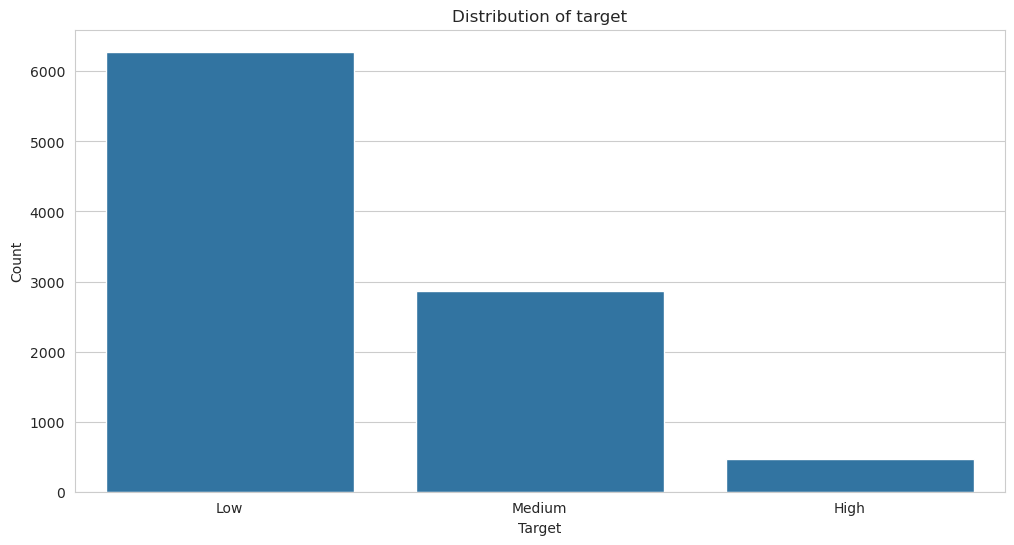

In [22]:
# Distribution of target
sns.countplot(data=train_data, x='Target')
plt.title('Distribution of target')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

- The data is imbalanced. The number of Low FHI is more than High FHI

In [23]:
counts = train_data['Target'].value_counts()
ratio_FHI = counts['Low'] / counts['High']
print(f'Ratio of Low FHI class to High FHI class is {ratio_FHI}:1')

Ratio of Low FHI class to High FHI class is 13.361702127659575:1


### 2. Target Vs Feature analysis

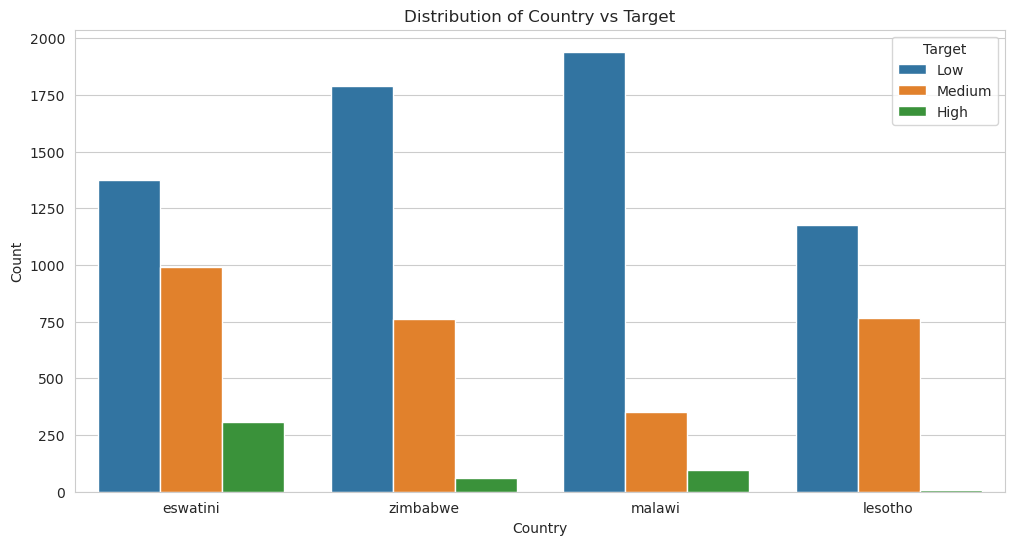

In [24]:
# Distribution of target vs country
sns.countplot(data=train_data, x='country', hue='Target')
plt.title('Distribution of Country vs Target')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

- In Lesotho, there's almost no small businesses with High FHI
- In all countries many business have Low FHI

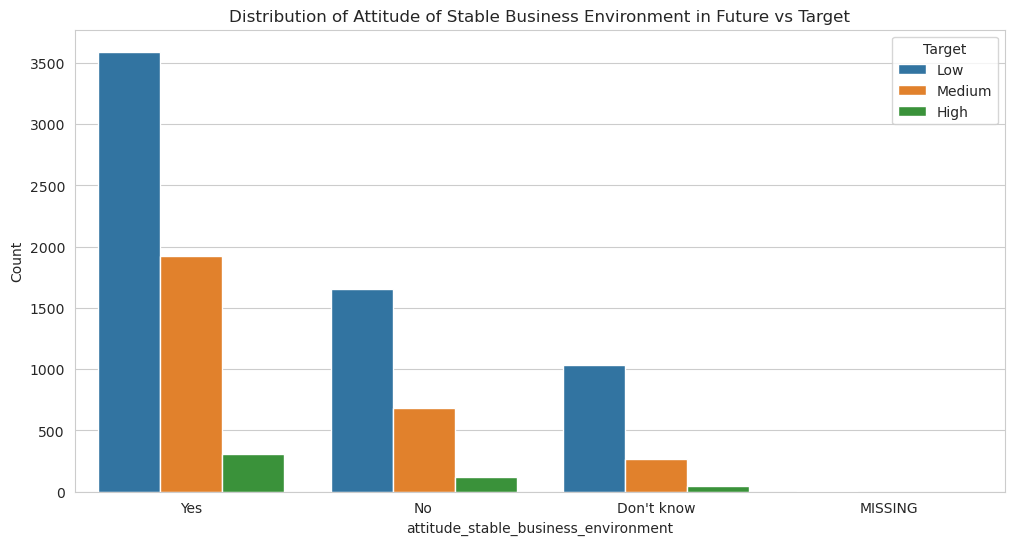

In [25]:
# Distribution of target vs attitude_stable_business_environment
sns.countplot(data=train_data, x='attitude_stable_business_environment', hue='Target')
plt.title('Distribution of Attitude of Stable Business Environment in Future vs Target')
plt.xlabel('attitude_stable_business_environment')
plt.ylabel('Count')
plt.show()

- Most owner who believe the country will have atable business environment in future still have Low FHI

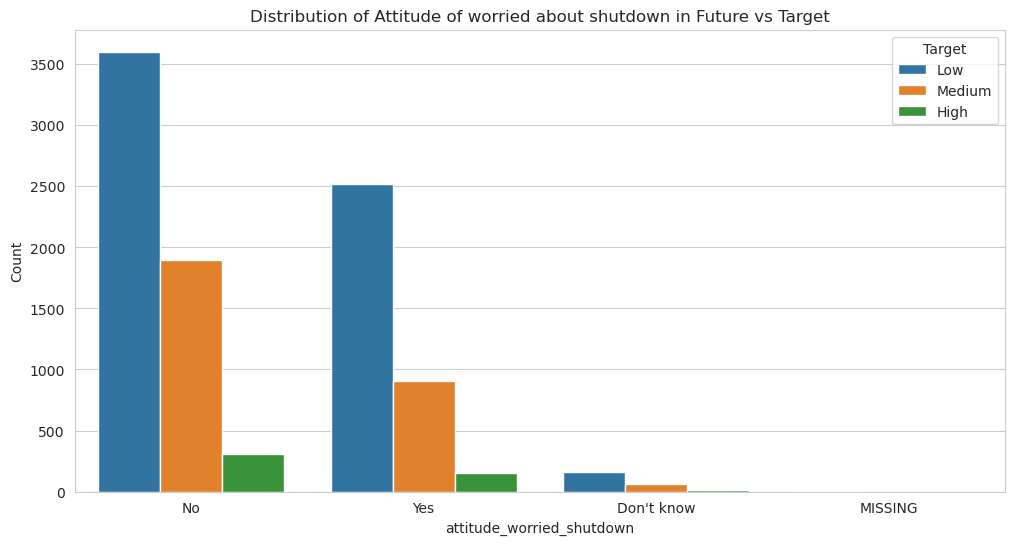

In [26]:
# Distribution of target vs attitude_stable_business_environment
sns.countplot(data=train_data, x='attitude_worried_shutdown', hue='Target')
plt.title('Distribution of Attitude of worried about shutdown in Future vs Target')
plt.xlabel('attitude_worried_shutdown')
plt.ylabel('Count')
plt.show()

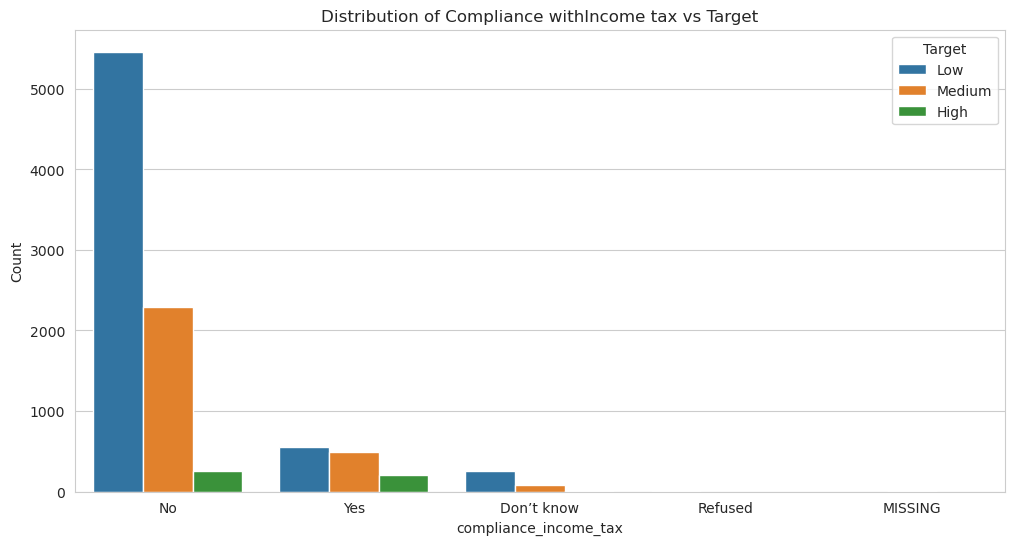

In [27]:
# Distribution of target vs attitude_stable_business_environment
sns.countplot(data=train_data, x='compliance_income_tax', hue='Target')
plt.title('Distribution of Compliance withIncome tax vs Target')
plt.xlabel('compliance_income_tax')
plt.ylabel('Count')
plt.show()

- Most business that are not compliant to income tax have Low and Medium FHI

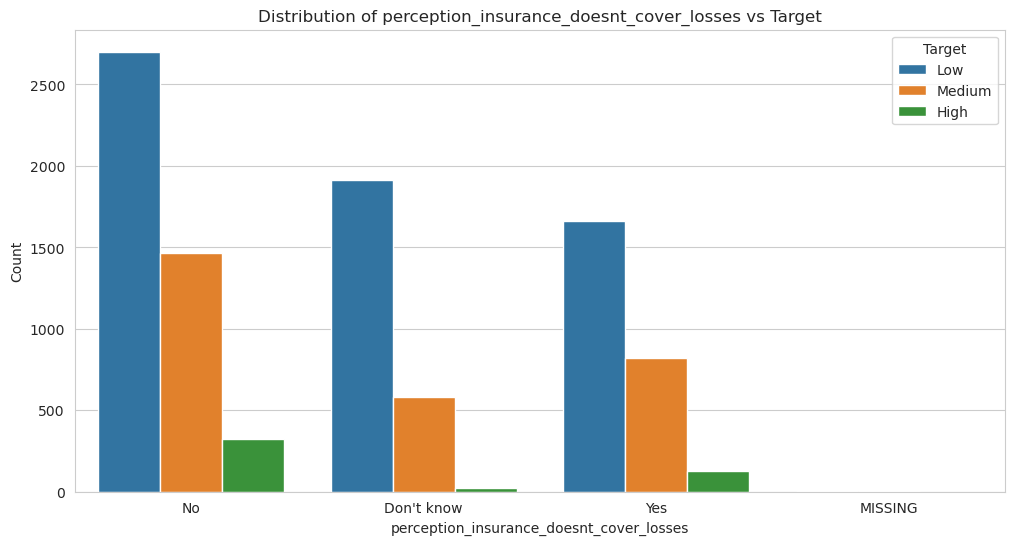

In [28]:
# Distribution of target vs attitude_stable_business_environment
sns.countplot(data=train_data, x='perception_insurance_doesnt_cover_losses', hue='Target')
plt.title('Distribution of perception_insurance_doesnt_cover_losses vs Target')
plt.xlabel('perception_insurance_doesnt_cover_losses')
plt.ylabel('Count')
plt.show()

- perception_insurance_doesnt_cover_losses the bussines suffers has no effect on the HFI of a business

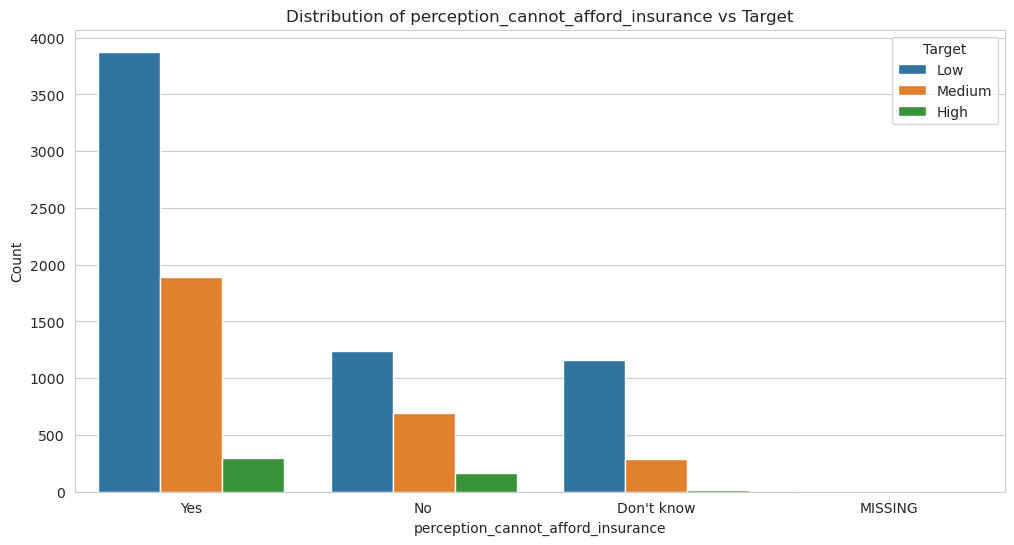

In [29]:
# Distribution of target vs perception_cannot_afford_insurance
sns.countplot(data=train_data, x='perception_cannot_afford_insurance', hue='Target')
plt.title('Distribution of perception_cannot_afford_insurance vs Target')
plt.xlabel('perception_cannot_afford_insurance')
plt.ylabel('Count')
plt.show()

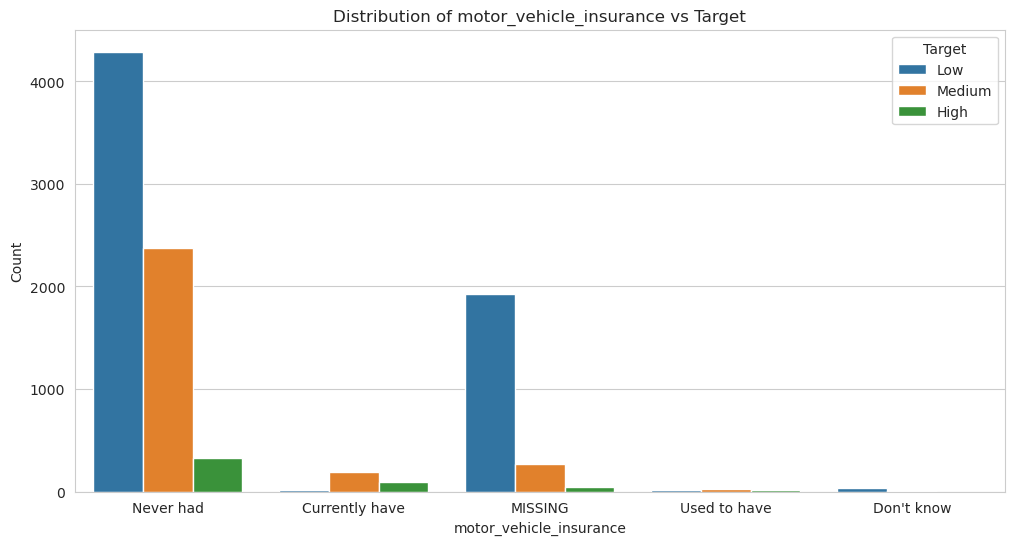

In [30]:
# Distribution of target vs motor_vehicle_insurance
sns.countplot(data=train_data, x='motor_vehicle_insurance', hue='Target')
plt.title('Distribution of motor_vehicle_insurance vs Target')
plt.xlabel('motor_vehicle_insurance')
plt.ylabel('Count')
plt.show()

- Owners who never had motor vehicle insurance or data is missing have Low HFI

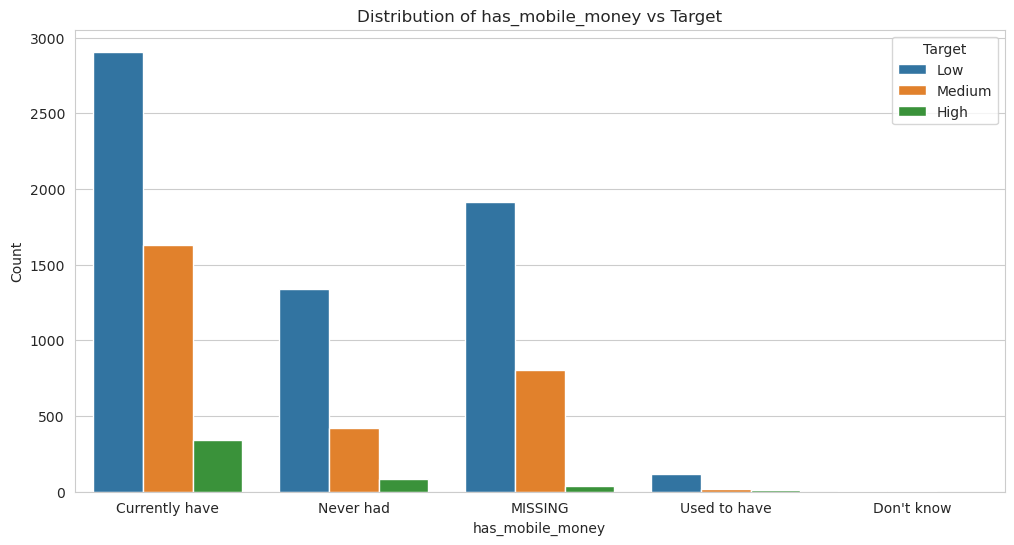

In [31]:
# Distribution of target vs has_mobile_money
sns.countplot(data=train_data, x='has_mobile_money', hue='Target')
plt.title('Distribution of has_mobile_money vs Target')
plt.xlabel('has_mobile_money')
plt.ylabel('Count')
plt.show()

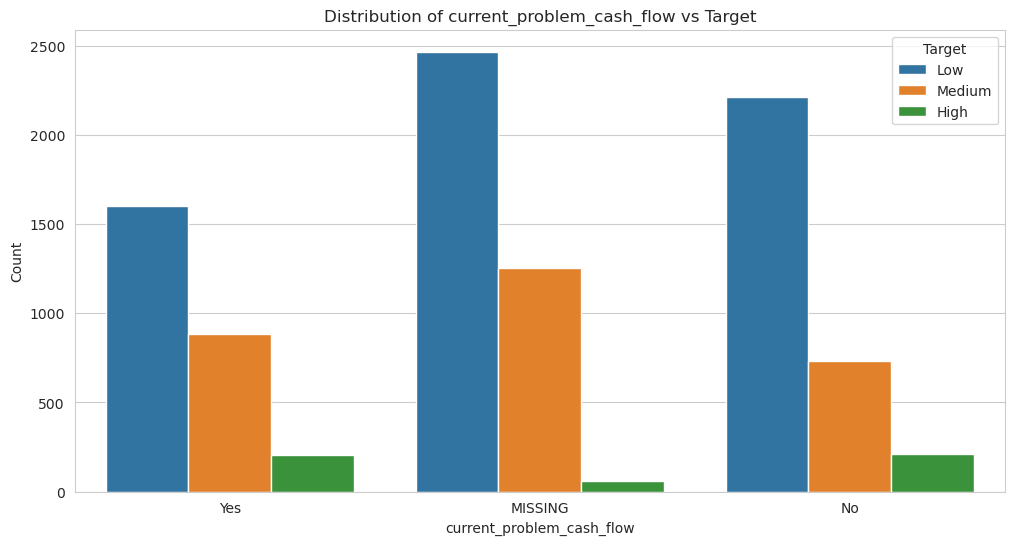

In [32]:
# Distribution of target vs current_problem_cash_flow
sns.countplot(data=train_data, x='current_problem_cash_flow', hue='Target')
plt.title('Distribution of current_problem_cash_flow vs Target')
plt.xlabel('current_problem_cash_flow')
plt.ylabel('Count')
plt.show()

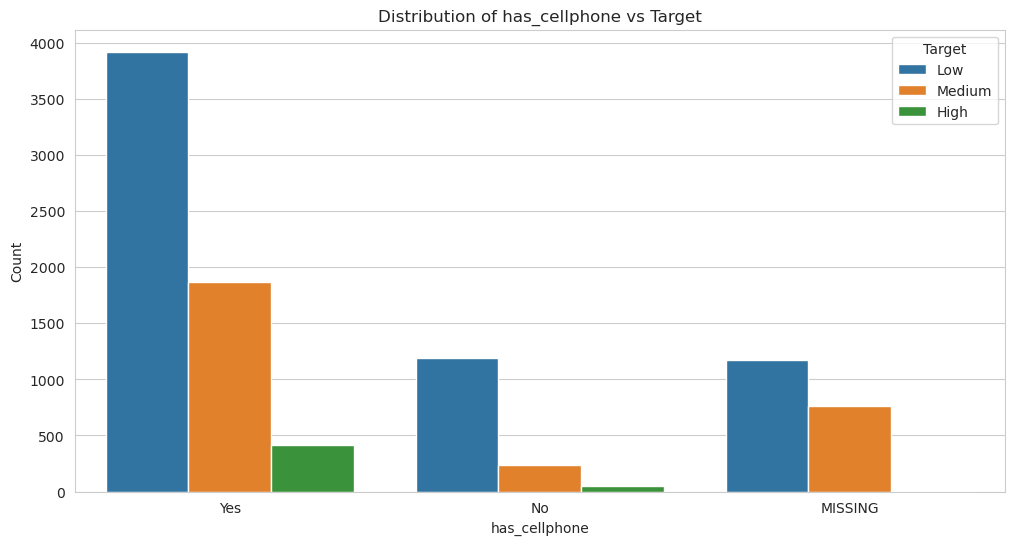

In [33]:
# Distribution of target vs has_cellphone
sns.countplot(data=train_data, x='has_cellphone', hue='Target')
plt.title('Distribution of has_cellphone vs Target')
plt.xlabel('has_cellphone')
plt.ylabel('Count')
plt.show()

- Most owners who have cellphones, their business's have Low FHI
- No onwer whose data is missing has High FHI

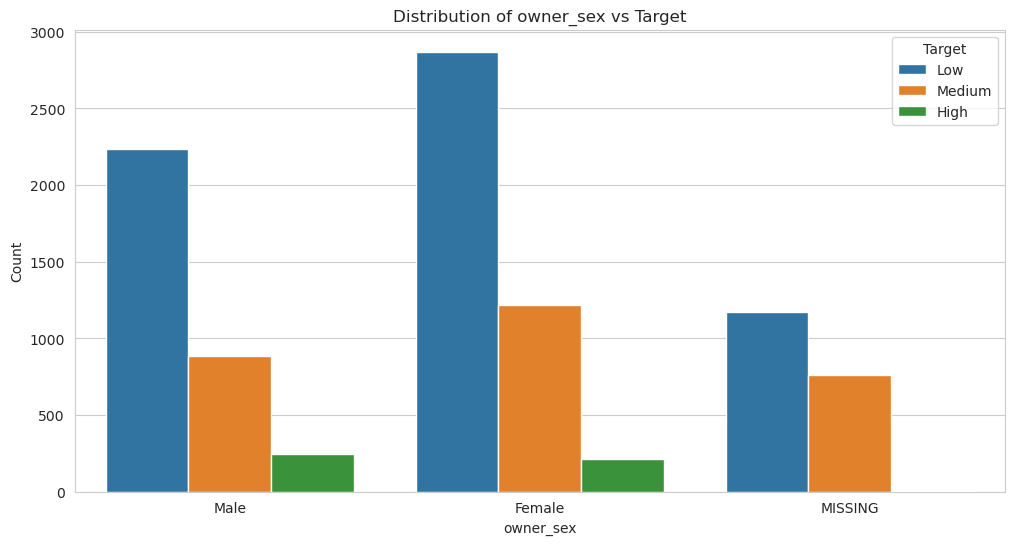

In [34]:
# Distribution of target vs owner_sex
sns.countplot(data=train_data, x='owner_sex', hue='Target')
plt.title('Distribution of owner_sex vs Target')
plt.xlabel('owner_sex')
plt.ylabel('Count')
plt.show()

- No owner whose sex status is missing has High HFI

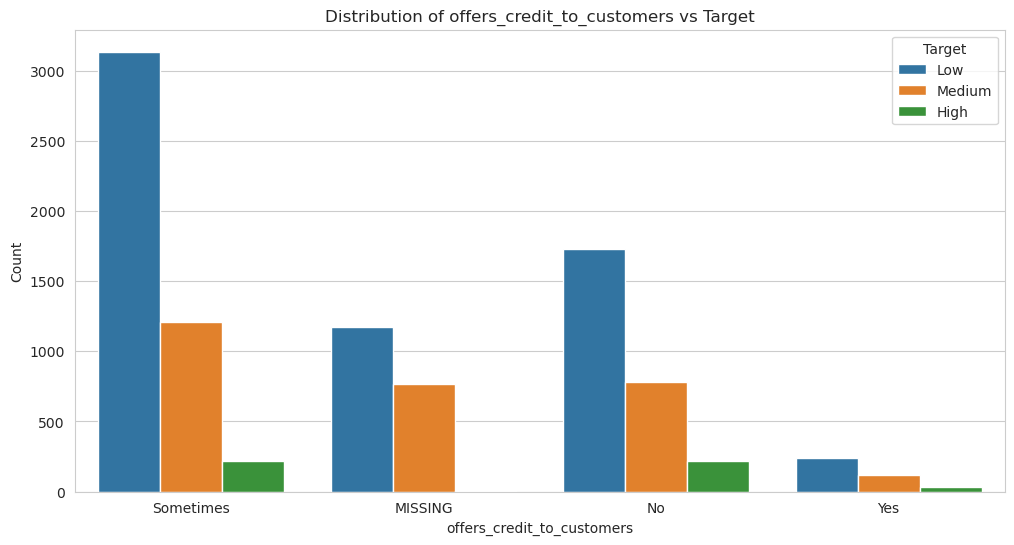

In [35]:
# Distribution of target vs offers_credit_to_customers
sns.countplot(data=train_data, x='offers_credit_to_customers', hue='Target')
plt.title('Distribution of offers_credit_to_customers vs Target')
plt.xlabel('offers_credit_to_customers')
plt.ylabel('Count')
plt.show()

- Most owners who sometimes give credit to customers have Low HFI
- No owner whose data on giving credit to customer is missing has HFI

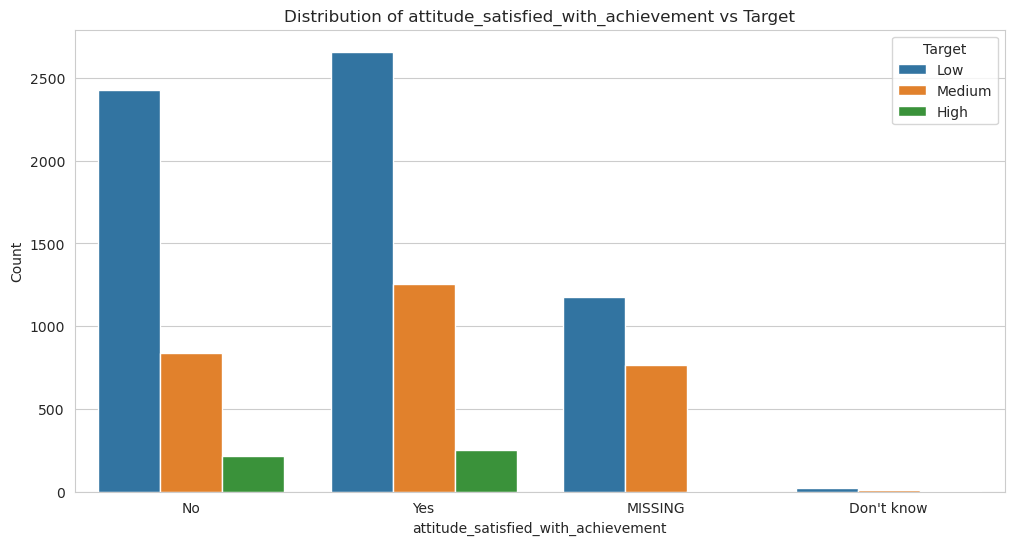

In [36]:
# Distribution of target vs attitude_satisfied_with_achievement
sns.countplot(data=train_data, x='attitude_satisfied_with_achievement', hue='Target')
plt.title('Distribution of attitude_satisfied_with_achievement vs Target')
plt.xlabel('attitude_satisfied_with_achievement')
plt.ylabel('Count')
plt.show()

- Whether the owners were satisfied with achivement this year or not, the HFI was Low

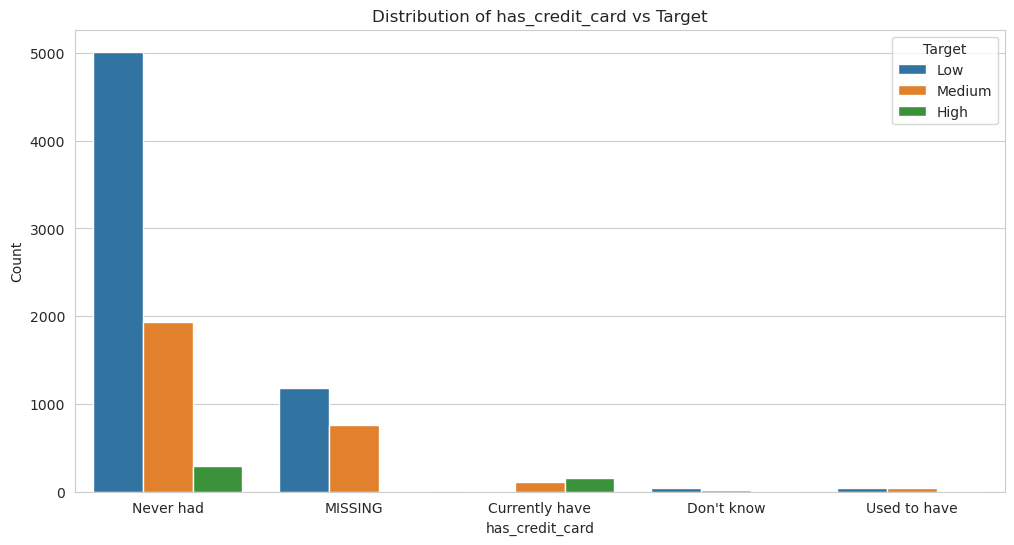

In [37]:
# Distribution of target vs has_credit_card
sns.countplot(data=train_data, x='has_credit_card', hue='Target')
plt.title('Distribution of has_credit_card vs Target')
plt.xlabel('has_credit_card')
plt.ylabel('Count')
plt.show()

- Most owners whos have never had a credit card, their business have low HFI

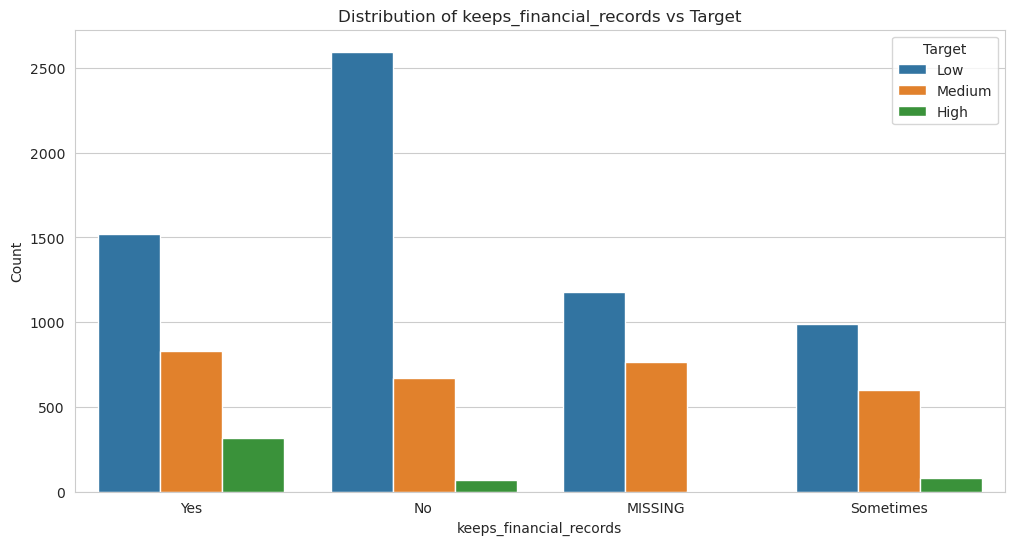

In [38]:
# Distribution of target vs keeps_financial_records
sns.countplot(data=train_data, x='keeps_financial_records', hue='Target')
plt.title('Distribution of keeps_financial_records vs Target')
plt.xlabel('keeps_financial_records')
plt.ylabel('Count')
plt.show()

- Most bussines owners who do not keep financial records have Low FHI

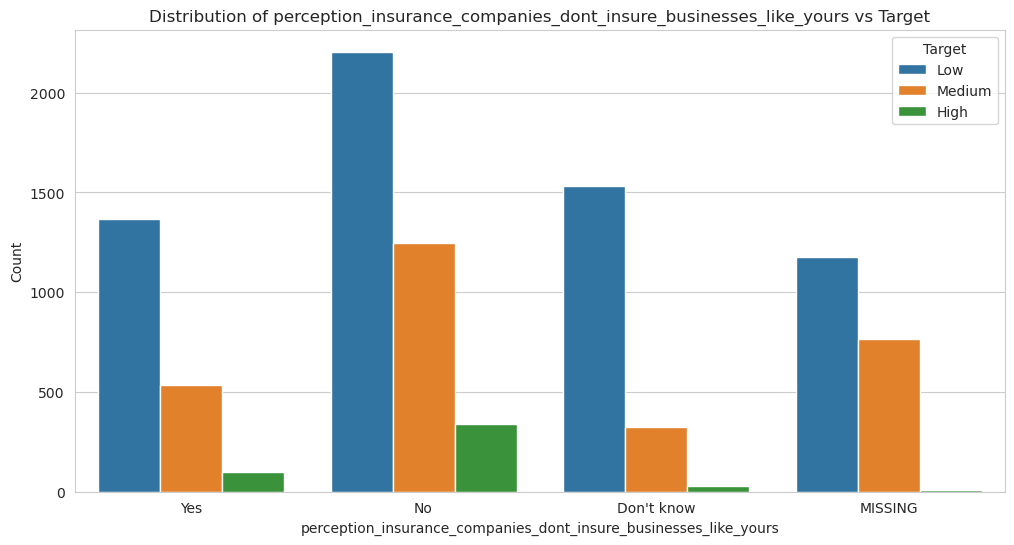

In [39]:
# Distribution of target vs perception_insurance_companies_dont_insure_businesses_like_yours
sns.countplot(data=train_data, x='perception_insurance_companies_dont_insure_businesses_like_yours', hue='Target')
plt.title('Distribution of perception_insurance_companies_dont_insure_businesses_like_yours vs Target')
plt.xlabel('perception_insurance_companies_dont_insure_businesses_like_yours')
plt.ylabel('Count')
plt.show()

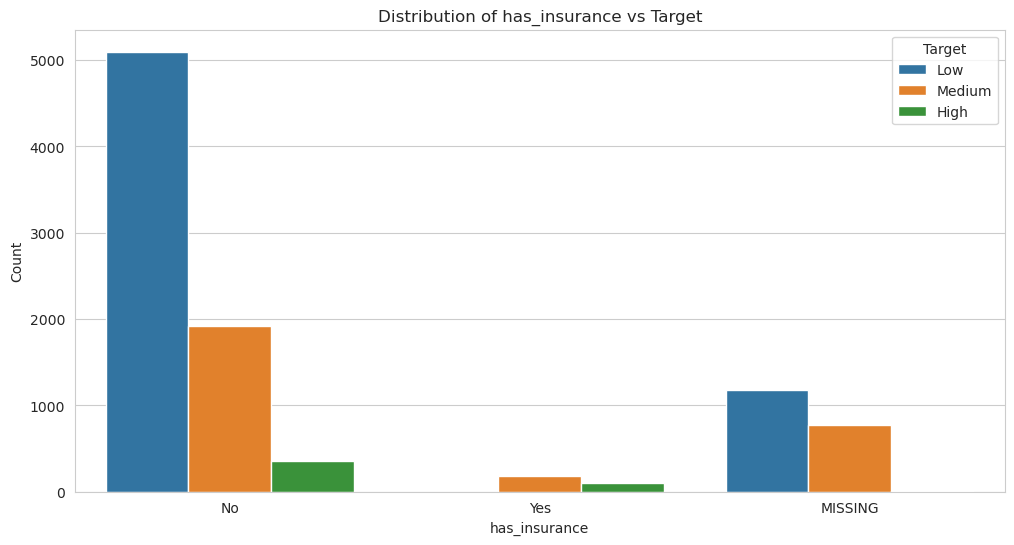

In [40]:
# Distribution of target vs has_insurance
sns.countplot(data=train_data, x='has_insurance', hue='Target')
plt.title('Distribution of has_insurance vs Target')
plt.xlabel('has_insurance')
plt.ylabel('Count')
plt.show()

- Most onwers who do not have insuarance, their businesses have Low HFI
- No owner who has insuarance has Low HFI
- For owners whose data on haveing insuarance is missing, none of their business have High HFI

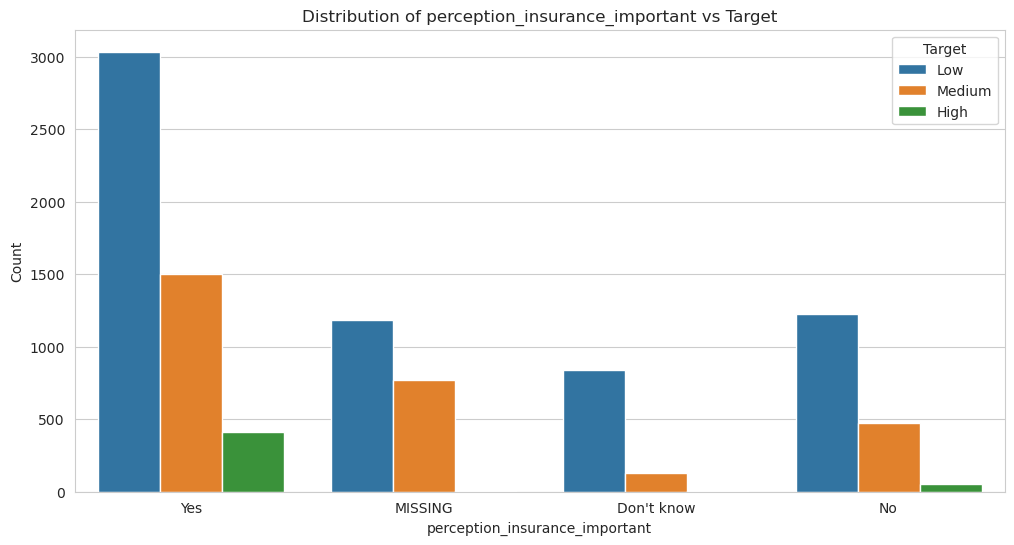

In [41]:
# Distribution of target vs perception_insurance_important
sns.countplot(data=train_data, x='perception_insurance_important', hue='Target')
plt.title('Distribution of perception_insurance_important vs Target')
plt.xlabel('perception_insurance_important')
plt.ylabel('Count')
plt.show()

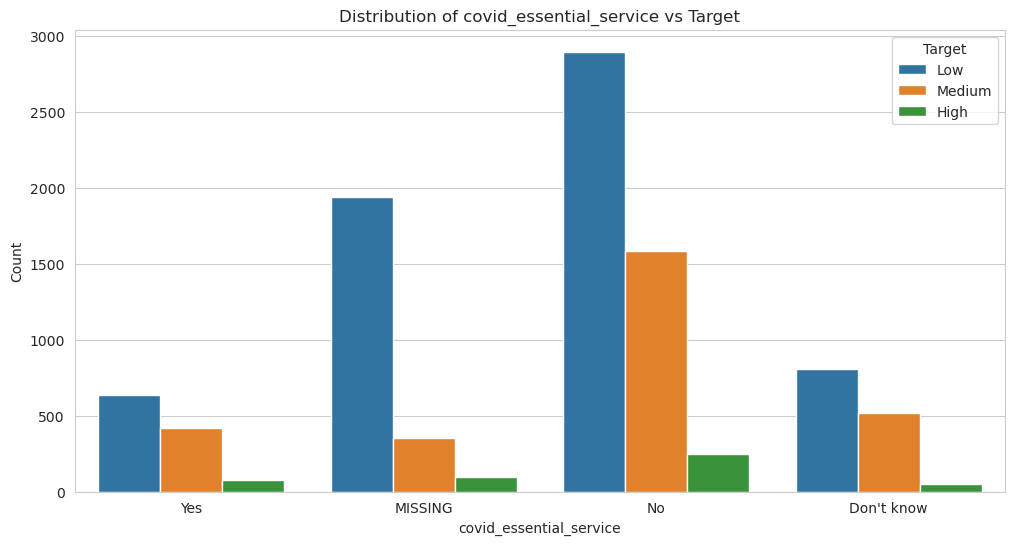

In [42]:
# Distribution of target vs covid_essential_service
sns.countplot(data=train_data, x='covid_essential_service', hue='Target')
plt.title('Distribution of covid_essential_service vs Target')
plt.xlabel('covid_essential_service')
plt.ylabel('Count')
plt.show()

- For most owners who do not have covid essential service or data is missing, their business have low HFI

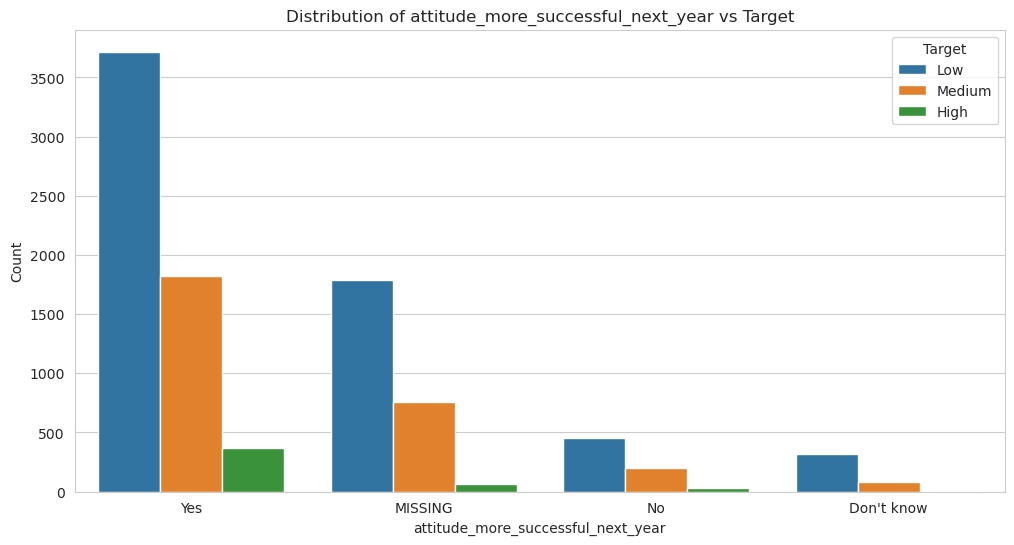

In [43]:
# Distribution of target vs attitude_more_successful_next_year
sns.countplot(data=train_data, x='attitude_more_successful_next_year', hue='Target')
plt.title('Distribution of attitude_more_successful_next_year vs Target')
plt.xlabel('attitude_more_successful_next_year')
plt.ylabel('Count')
plt.show()

- For most owners who have an attitude to be more successful next year or data is missing, their business have Low HFI

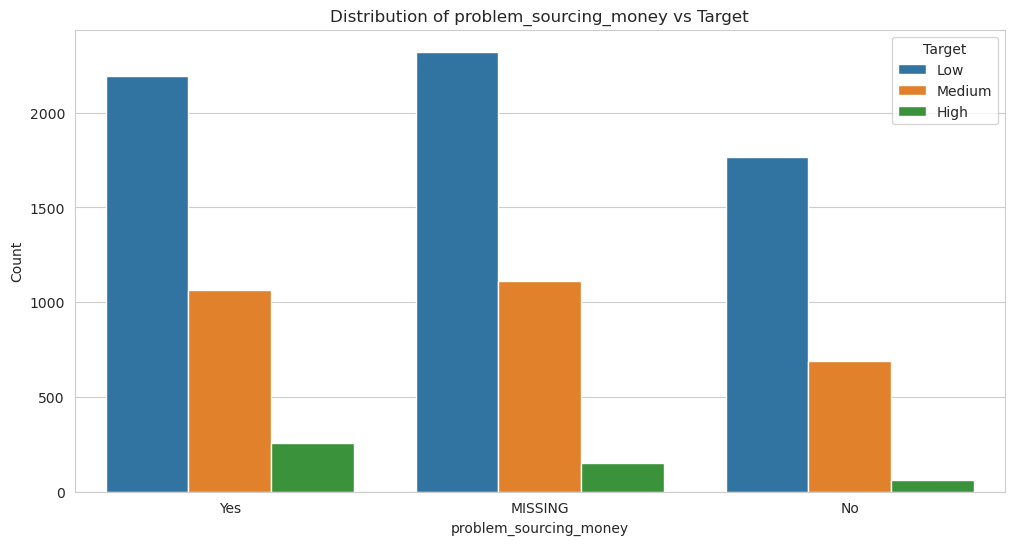

In [44]:
# Distribution of target vs problem_sourcing_money
sns.countplot(data=train_data, x='problem_sourcing_money', hue='Target')
plt.title('Distribution of problem_sourcing_money vs Target')
plt.xlabel('problem_sourcing_money')
plt.ylabel('Count')
plt.show()

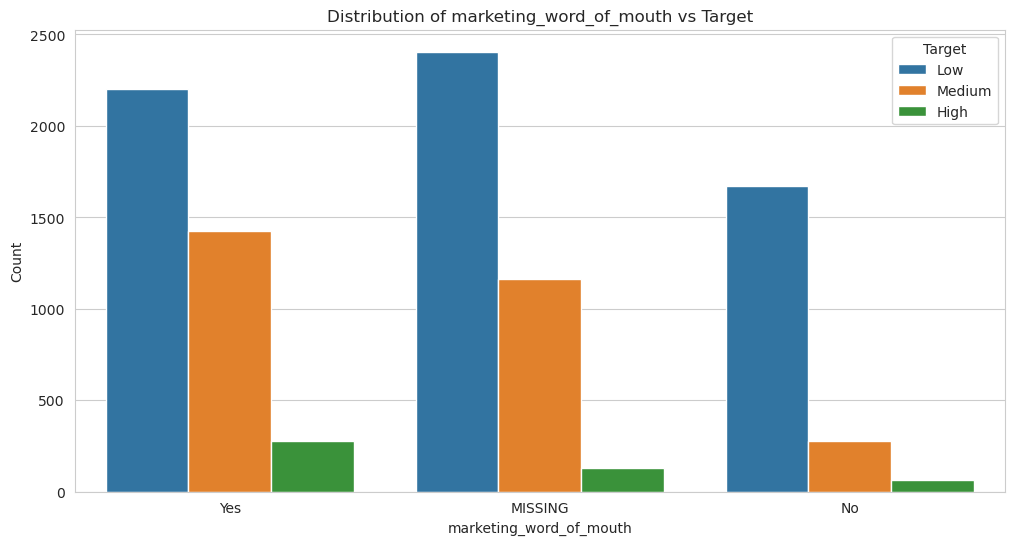

In [45]:
# Distribution of target vs marketing_word_of_mouth
sns.countplot(data=train_data, x='marketing_word_of_mouth', hue='Target')
plt.title('Distribution of marketing_word_of_mouth vs Target')
plt.xlabel('marketing_word_of_mouth')
plt.ylabel('Count')
plt.show()

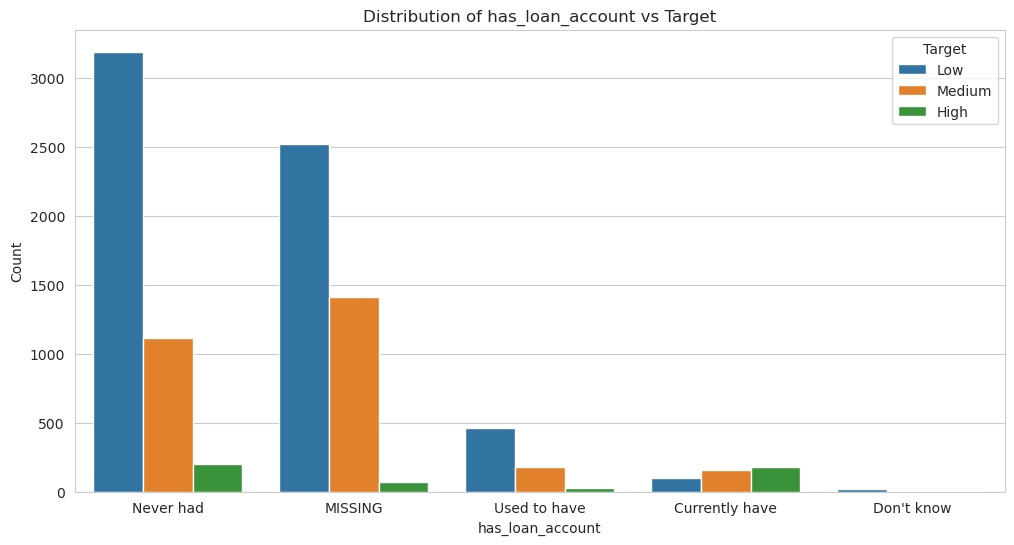

In [46]:
# Distribution of target vs has_loan_account
sns.countplot(data=train_data, x='has_loan_account', hue='Target')
plt.title('Distribution of has_loan_account vs Target')
plt.xlabel('has_loan_account')
plt.ylabel('Count')
plt.show()

- For most owners who have never had a loan account or data is missing, their bussiness have Low HFI

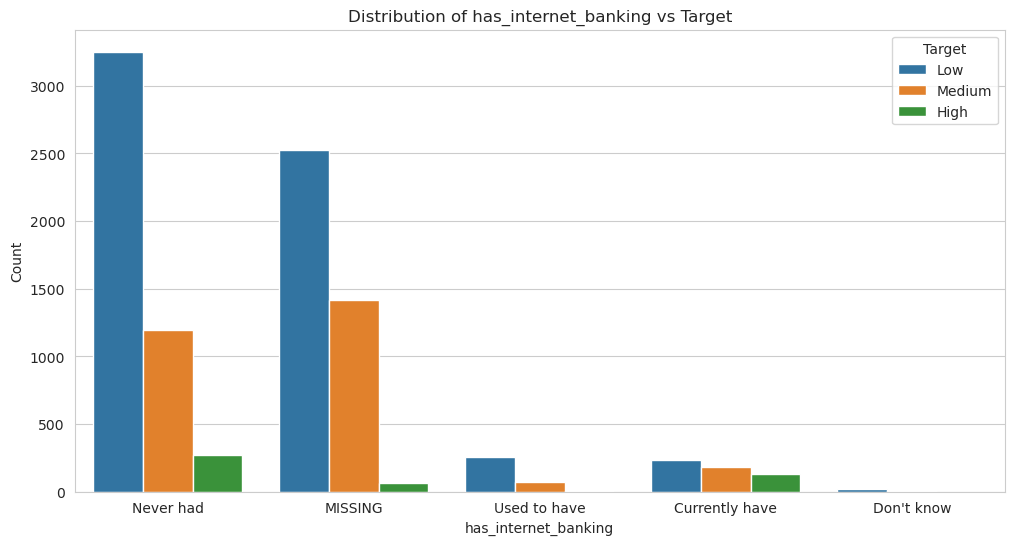

In [47]:
# Distribution of target vs has_internet_banking
sns.countplot(data=train_data, x='has_internet_banking', hue='Target')
plt.title('Distribution of has_internet_banking vs Target')
plt.xlabel('has_internet_banking')
plt.ylabel('Count')
plt.show()

- For most owners who never had internet banking or data is missing, their businesses have low HFI

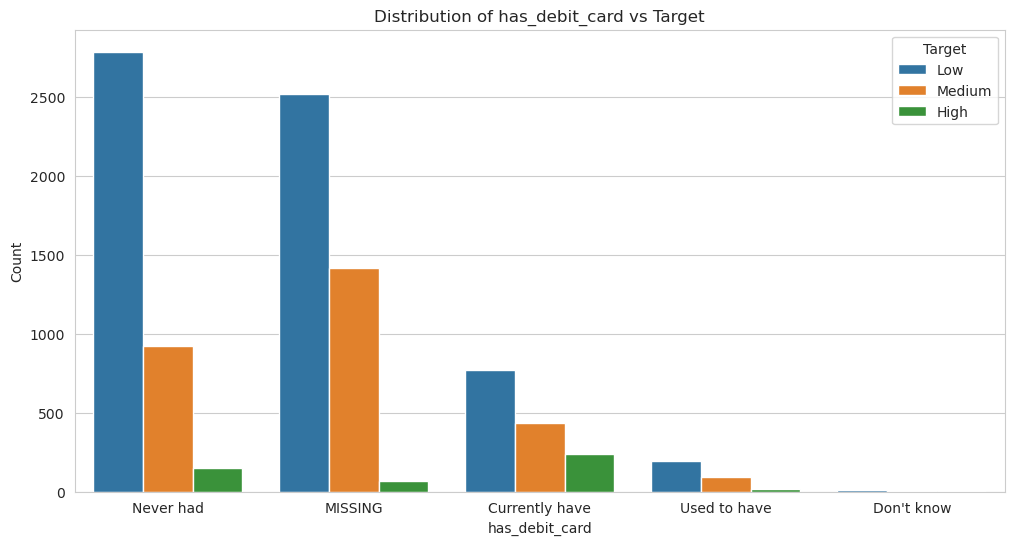

In [48]:
# Distribution of target vs has_debit_card
sns.countplot(data=train_data, x='has_debit_card', hue='Target')
plt.title('Distribution of has_debit_card vs Target')
plt.xlabel('has_debit_card')
plt.ylabel('Count')
plt.show()

- For most owners who have never had a debit card or data is missing, their businesses have Low HFI

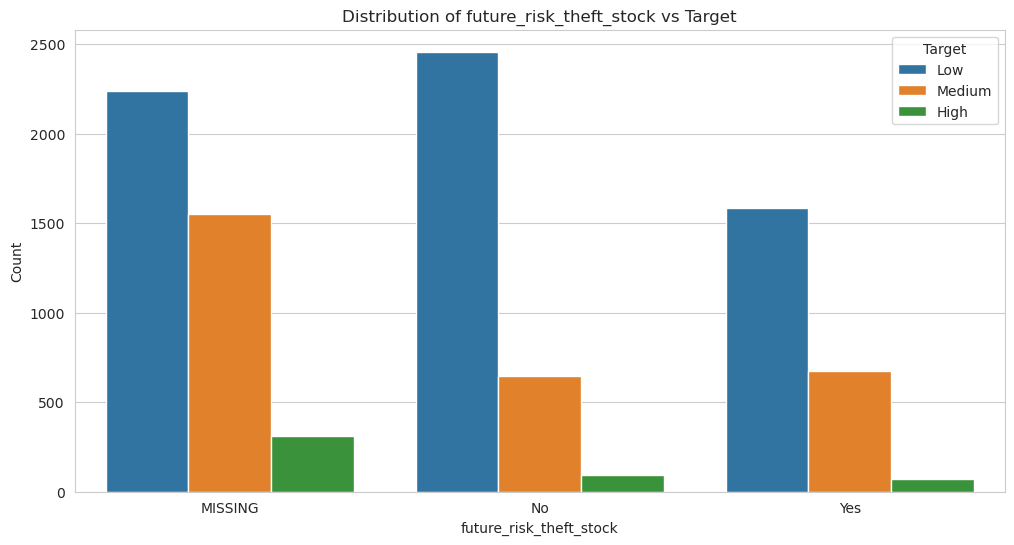

In [49]:
# Distribution of target vs future_risk_theft_stock
sns.countplot(data=train_data, x='future_risk_theft_stock', hue='Target')
plt.title('Distribution of future_risk_theft_stock vs Target')
plt.xlabel('future_risk_theft_stock')
plt.ylabel('Count')
plt.show()

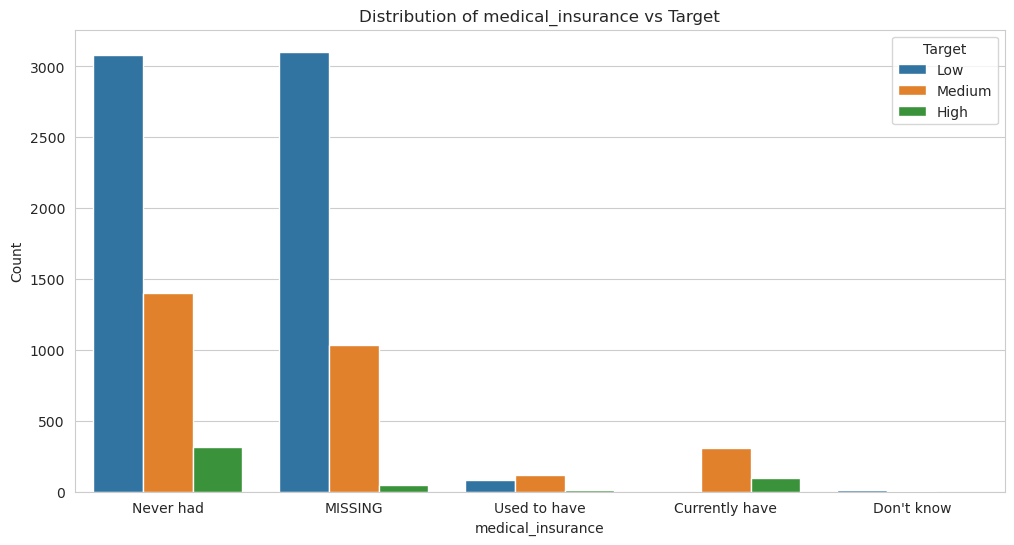

In [50]:
# Distribution of target vs medical_insurance
sns.countplot(data=train_data, x='medical_insurance', hue='Target')
plt.title('Distribution of medical_insurance vs Target')
plt.xlabel('medical_insurance')
plt.ylabel('Count')
plt.show()

- For most owners who have never had a medical insurance or data is missing, their businesses have Low HFI
- No owner who has medical insurance, and their business has low HFI

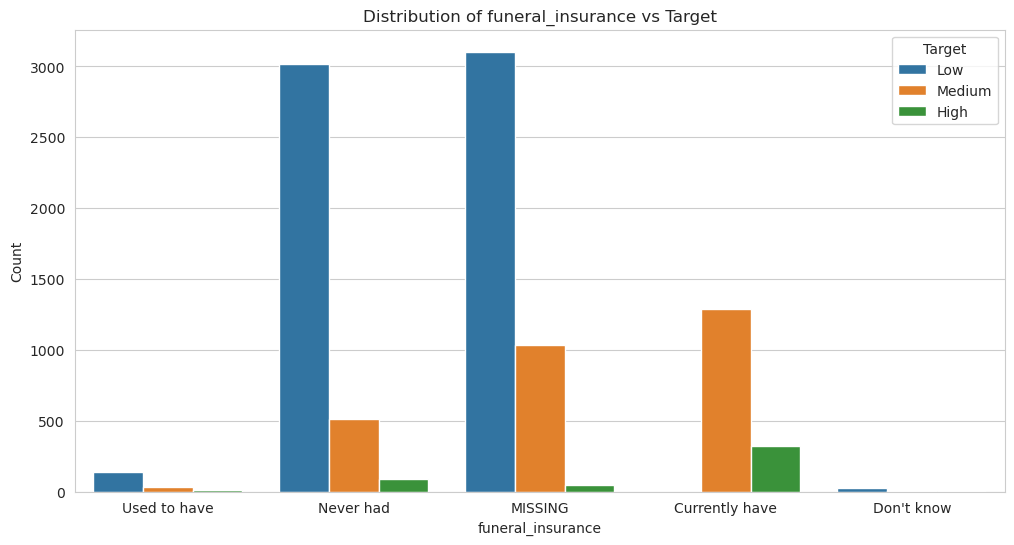

In [51]:
# Distribution of target vs funeral_insurance
sns.countplot(data=train_data, x='funeral_insurance', hue='Target')
plt.title('Distribution of funeral_insurance vs Target')
plt.xlabel('funeral_insurance')
plt.ylabel('Count')
plt.show()

- For most owners who have never had a funeral insurance or data is missing, their businesses have Low HFI
- No owner who has funeral insurance, and their business has low HFI

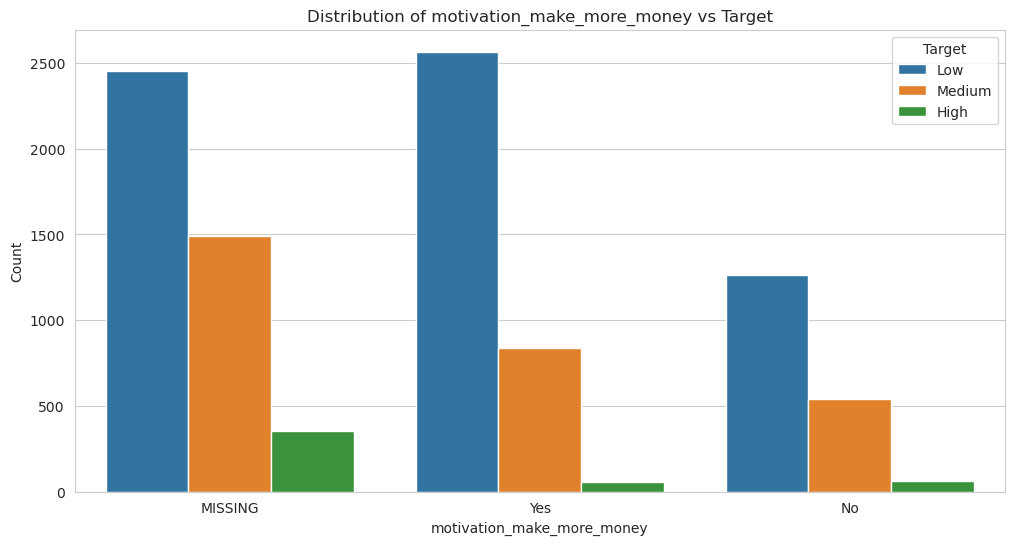

In [52]:
# Distribution of target vs motivation_make_more_money
sns.countplot(data=train_data, x='motivation_make_more_money', hue='Target')
plt.title('Distribution of motivation_make_more_money vs Target')
plt.xlabel('motivation_make_more_money')
plt.ylabel('Count')
plt.show()

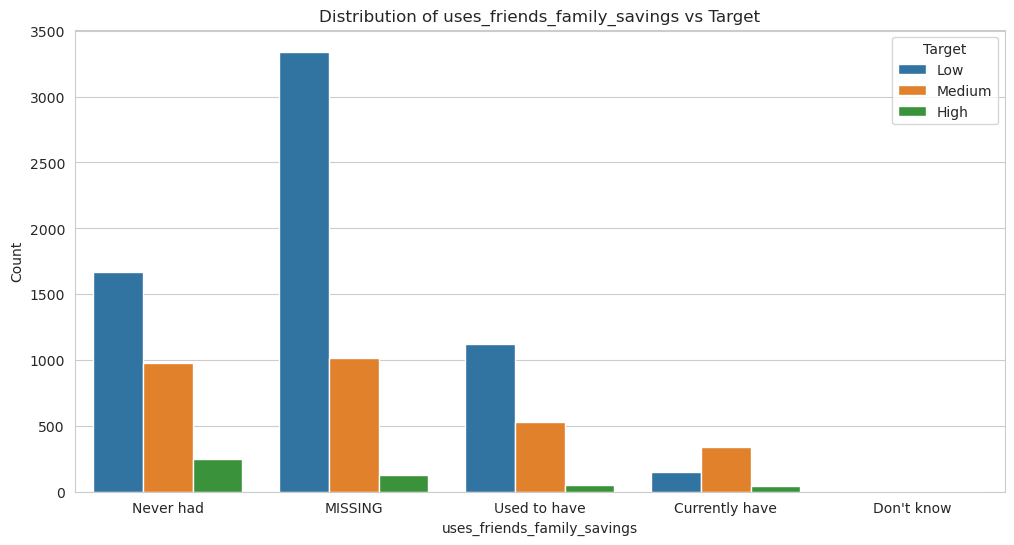

In [53]:
# Distribution of target vs uses_friends_family_savings
sns.countplot(data=train_data, x='uses_friends_family_savings', hue='Target')
plt.title('Distribution of uses_friends_family_savings vs Target')
plt.xlabel('uses_friends_family_savings')
plt.ylabel('Count')
plt.show()

- For most owners whose data on where uses friends or family saving is missing, their businesses have low HFI

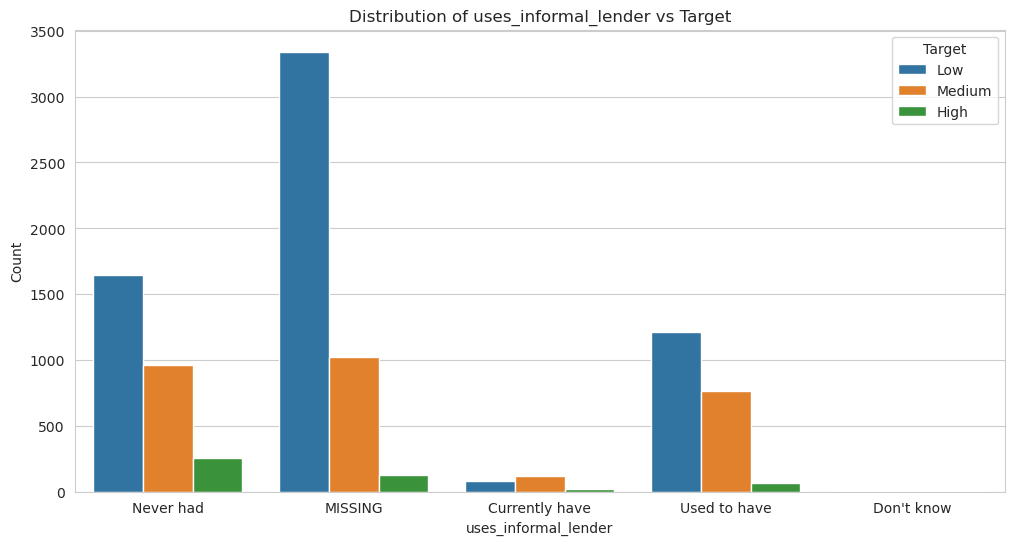

In [54]:
# Distribution of target vs uses_informal_lender
sns.countplot(data=train_data, x='uses_informal_lender', hue='Target')
plt.title('Distribution of uses_informal_lender vs Target')
plt.xlabel('uses_informal_lender')
plt.ylabel('Count')
plt.show()

- For most owners whose data on whether  they use an informal lender is missing, their businesses have low HFI

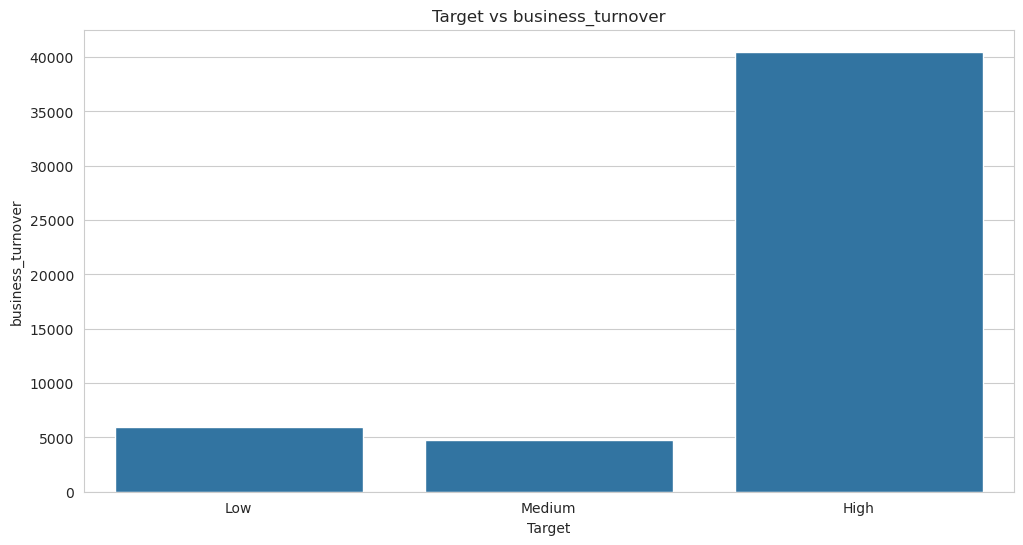

In [55]:
sns.barplot(
    x="Target",
    y="business_turnover",
    data=train_data,
    estimator=np.median,
    errorbar=None
)
plt.title('Target vs business_turnover')
plt.show()

- owners with high business turnover have high HFI,
- businesses with more than 7000 in turonver have high HFI

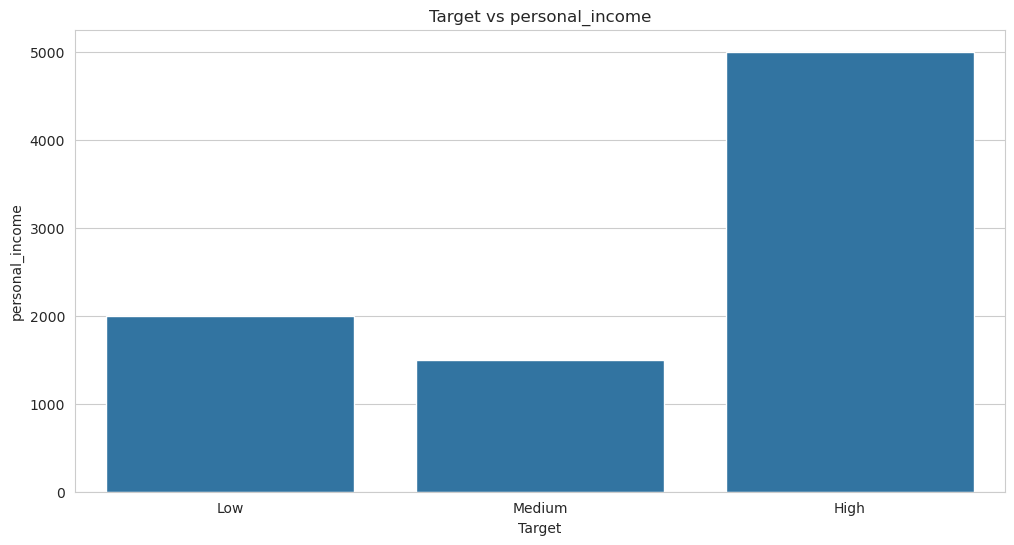

In [56]:
sns.barplot(
    x="Target",
    y="personal_income",
    data=train_data,
    estimator=np.median,
    errorbar=None
)
plt.title('Target vs personal_income')
plt.show()

- owners with high personal income, above 2000, have high HFI

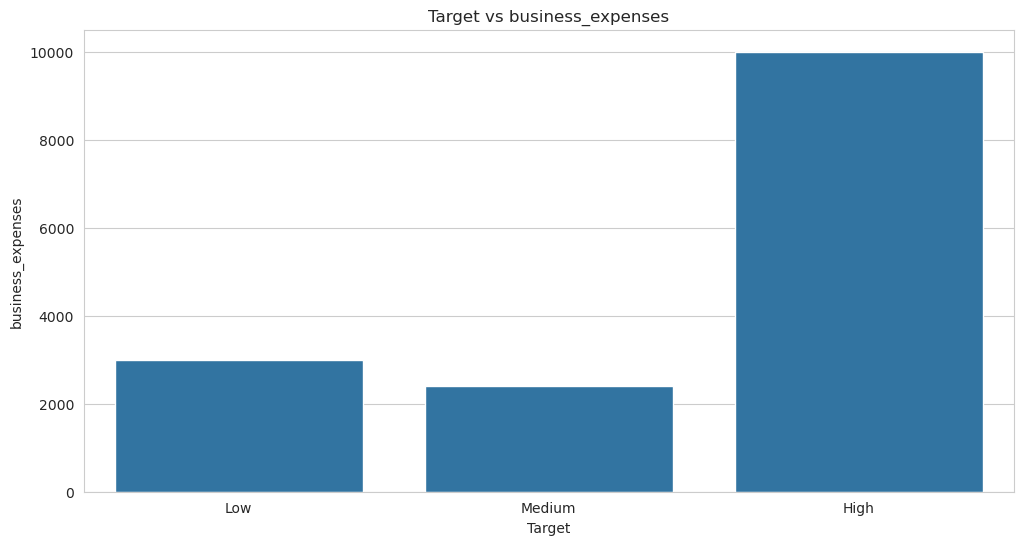

In [57]:
sns.barplot(
    x="Target",
    y="business_expenses",
    data=train_data,
    estimator=np.median,
    errorbar=None
)
plt.title('Target vs business_expenses')
plt.show()

- owners with business expensess of 3500 and above have high HFI

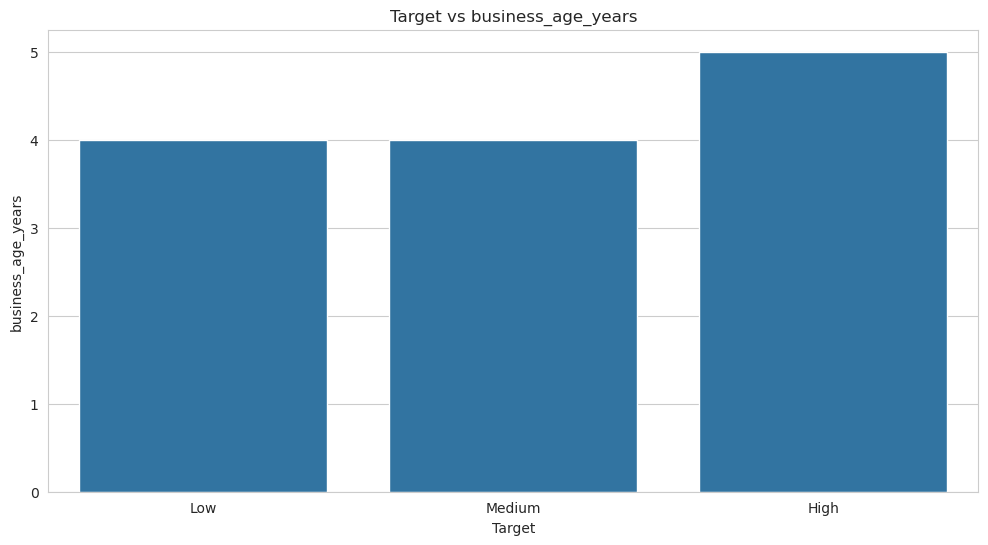

In [58]:
sns.barplot(
    x="Target",
    y="business_age_years",
    data=train_data,
    estimator=np.median,
    errorbar=None
)
plt.title('Target vs business_age_years')
plt.show()

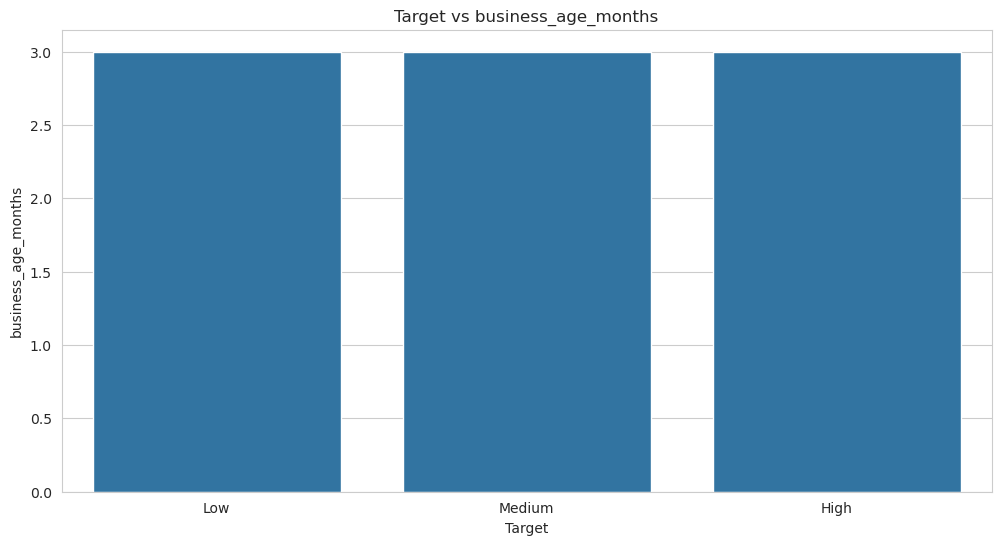

In [59]:
sns.barplot(
    x="Target",
    y="business_age_months",
    data=train_data,
    estimator=np.median,
    errorbar=None
)
plt.title('Target vs business_age_months')
plt.show()

In [60]:
numerical_cols

['owner_age',
 'personal_income',
 'business_expenses',
 'business_turnover',
 'business_age_years',
 'business_age_months']

### 3. Multivariate Analysis

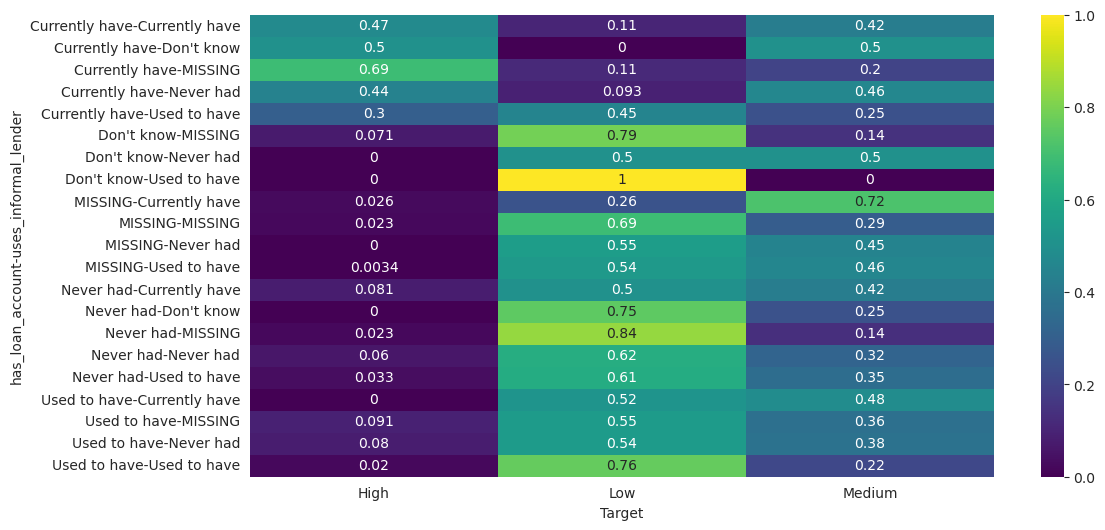

In [61]:
pivot = pd.crosstab(
    index=[train_data['has_loan_account'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners currently have a loan account and inforamtion on using informal lender is missing, they have a 69% chance of having high HFI
- For owners that never had a loan account and information on using informal lender is missing, they have a 84% chance of having a low HFI
- For owners that never had a loan account and information on using informal lender is Don't know, they have a 75% chance of having a low HFI
- For owners that used to have a loan account and information on using informal lender is used to have, they have a 76% chance of having a low HFI
- For owners that information on having a loan account is missing andthey currently use an informal lender, they have a 72% chance of having a medium HFI

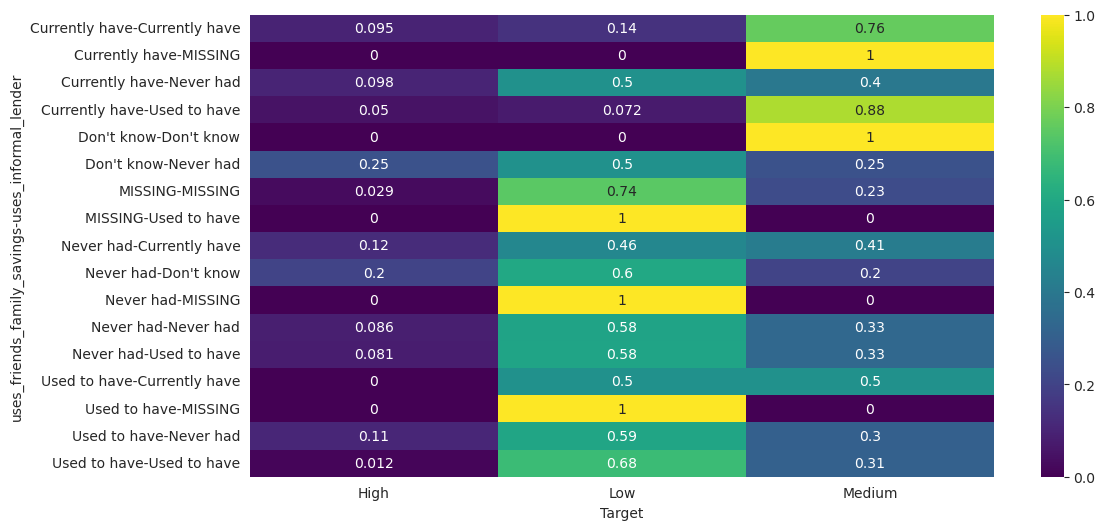

In [62]:
pivot = pd.crosstab(
    index=[train_data['uses_friends_family_savings'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who currently uses friends and families savings and currently have an informal lender, they have a 76% chance of having a medium HFI
- For owners who currently uses friends and families savings and used to have an informal lender, they have a 88% chance of having a medium HFI
- For owners whose information on using friends and family savings and using an informal lender is missing, they have a 74% chance of having a low HFI
- For owners used to use friends and family savings and used to have an informal lender, they have a 68% chance of having a low HFI

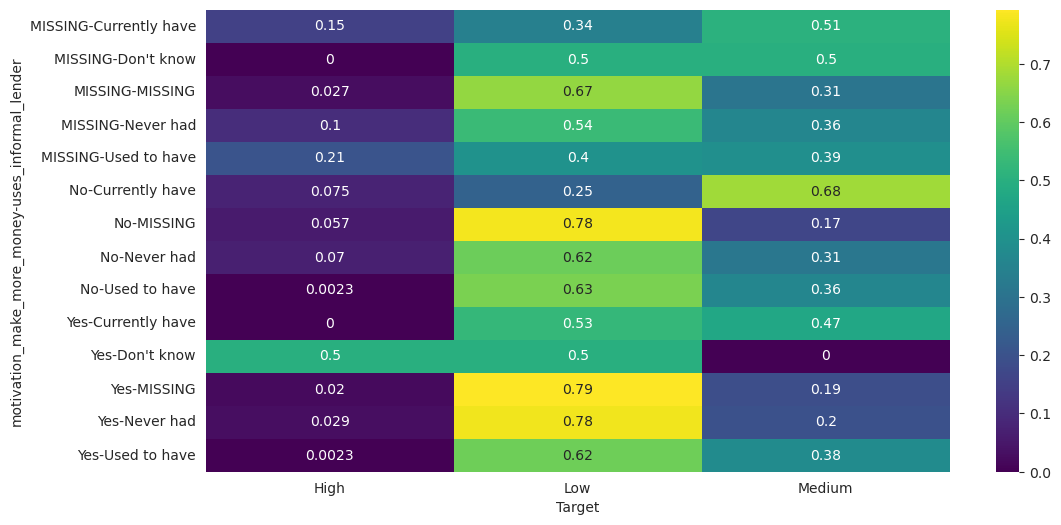

In [63]:
pivot = pd.crosstab(
    index=[train_data['motivation_make_more_money'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who do not have motivation to make more money and information on using informal lender is missing, they have 78% chance of having a low HFI
- For owners who have motivation to make more money and information on using informal lender is missing, they have 79% chance of having a low HFI
- For owners who have motivation to make more money and never had an informal lender, they have 78% chance of having a low HFI
- For owners who have motivation to make more money and used to have an informal lender, they have 62% chance of having a low HFI

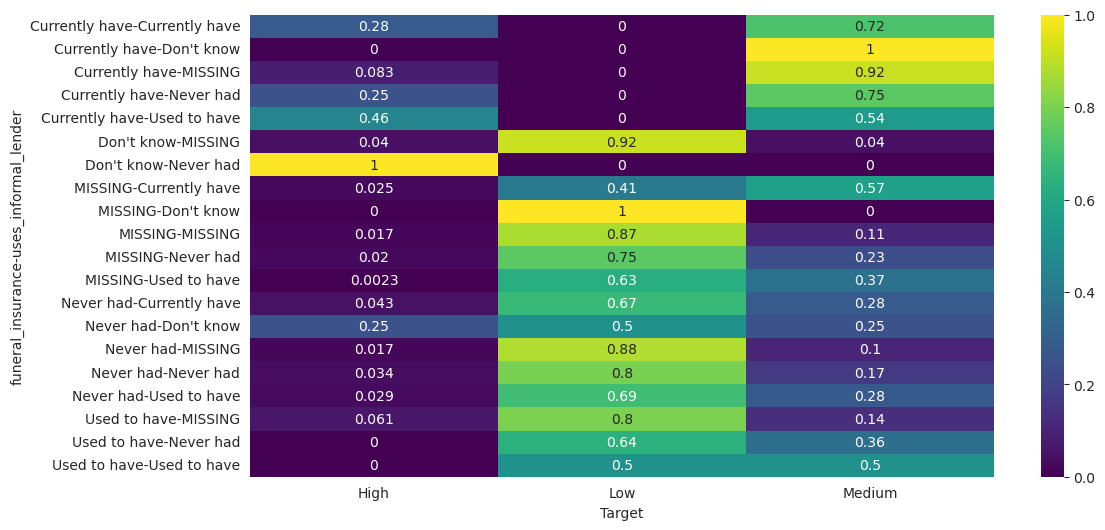

In [64]:
pivot = pd.crosstab(
    index=[train_data['funeral_insurance'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who currently have funereal insurance and currently use informal lender, they have a 72% chance of having a medium HFI
- For owners who currently have funereal insurance and never had an informal lender, they have a 72% chance of having a medium HFI

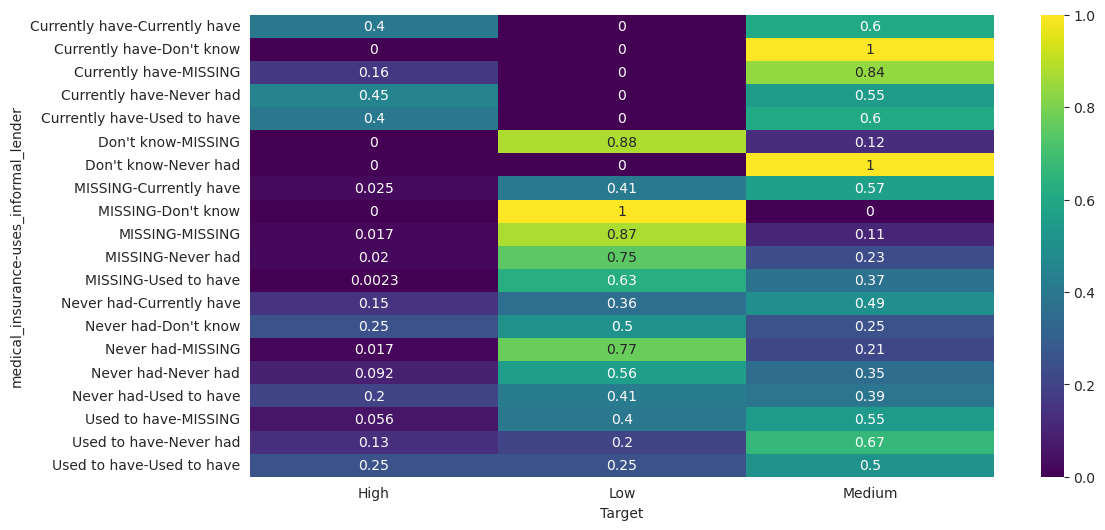

In [65]:
pivot = pd.crosstab(
    index=[train_data['medical_insurance'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who currently have medical insurance and information on uses informal lender is don't know, they have a 100% chance of having a medium HFI
- For owners who dont't know medical insurance and never had an informal lender, they have a 100% chance of having a medium HFI

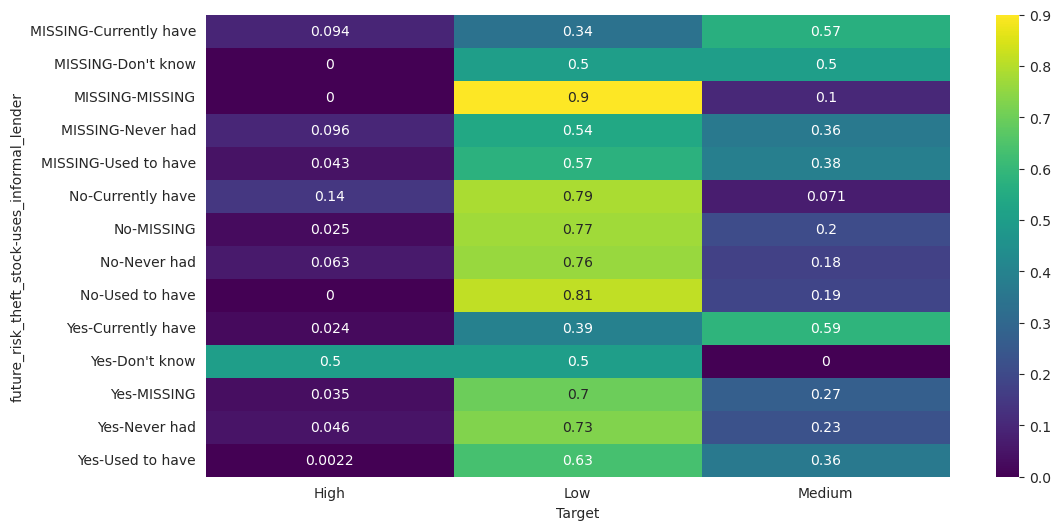

In [66]:
pivot = pd.crosstab(
    index=[train_data['future_risk_theft_stock'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

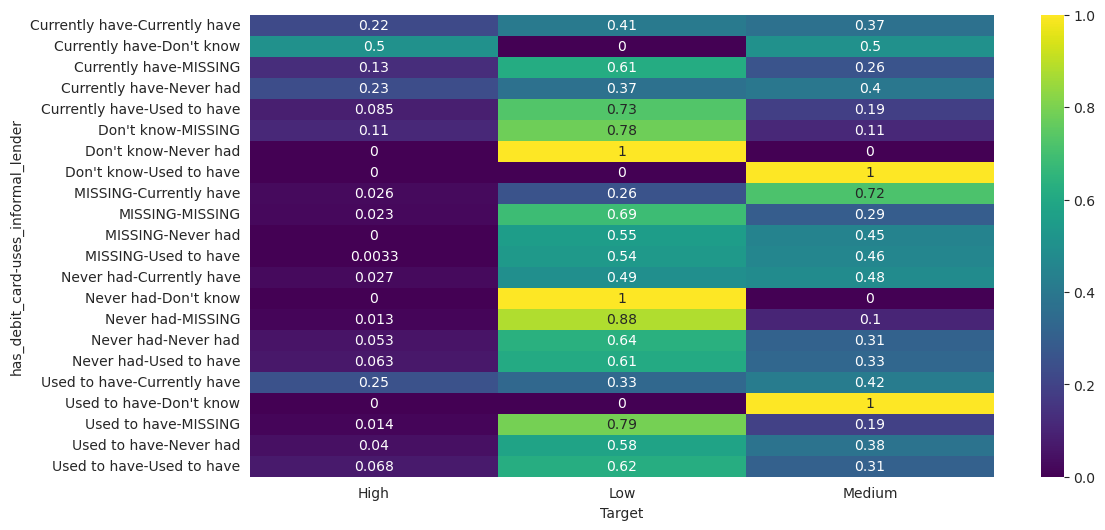

In [67]:
pivot = pd.crosstab(
    index=[train_data['has_debit_card'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who dont know if they have a debit card and never had an informal lender, they have a 100% chance of having low HFI
- For owners who never had have a debit card and dont know if they use an informal lender, they have a 100% chance of having low HFI
- For owners who dont know if they have a debit card and used to have an informal lender, they have a 100% chance of having meduim HFI
- For owners used to have debit card and who dont know if they have an informal lender, they have a 100% chance of having meduim HFI

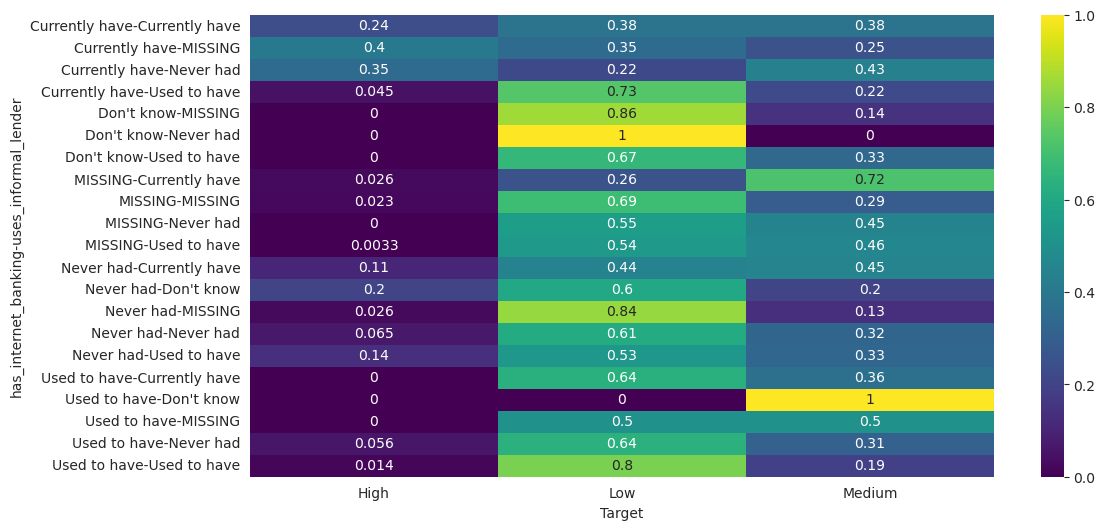

In [68]:
pivot = pd.crosstab(
    index=[train_data['has_internet_banking'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who used to have internet banking and dont know in using informal lender, they have 100% of having medium HFI
- For owners who dont know if they had internet banking and never have used an informal lender, they have 100% of having low HFI
- For owners who used to have internet banking and used to have an informal lender, they have 80% of having low HFI

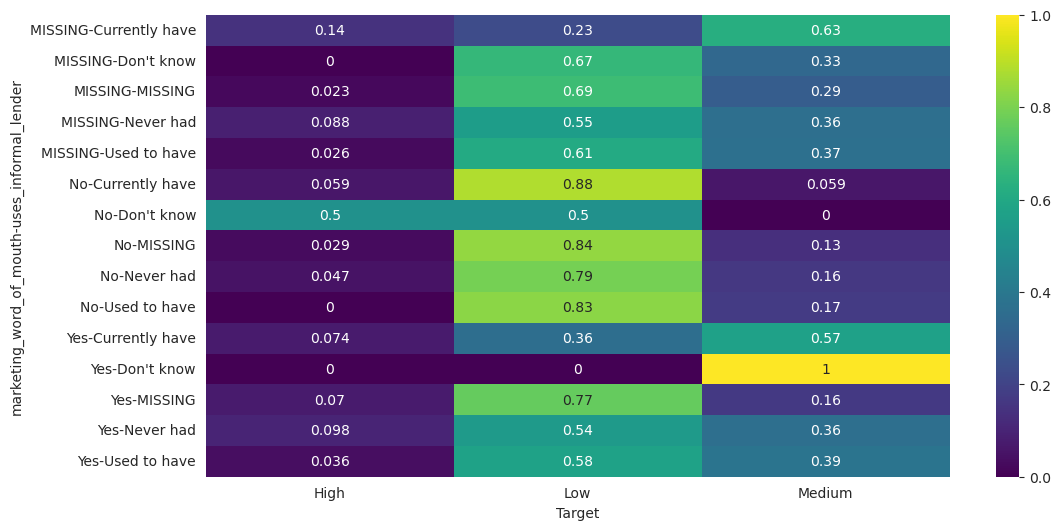

In [69]:
pivot = pd.crosstab(
    index=[train_data['marketing_word_of_mouth'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who use marketing word of mouth and dont know if they use an informal lender, they have a 100% chance of having medium HFI
- For owners who do not use marketing word of mouth and currently have an informal lender, they have 88% chance of having a low HFI
- For owners who do not use marketing word of mouth and used to have an informal lender, they have 83% chance of having a low HFI

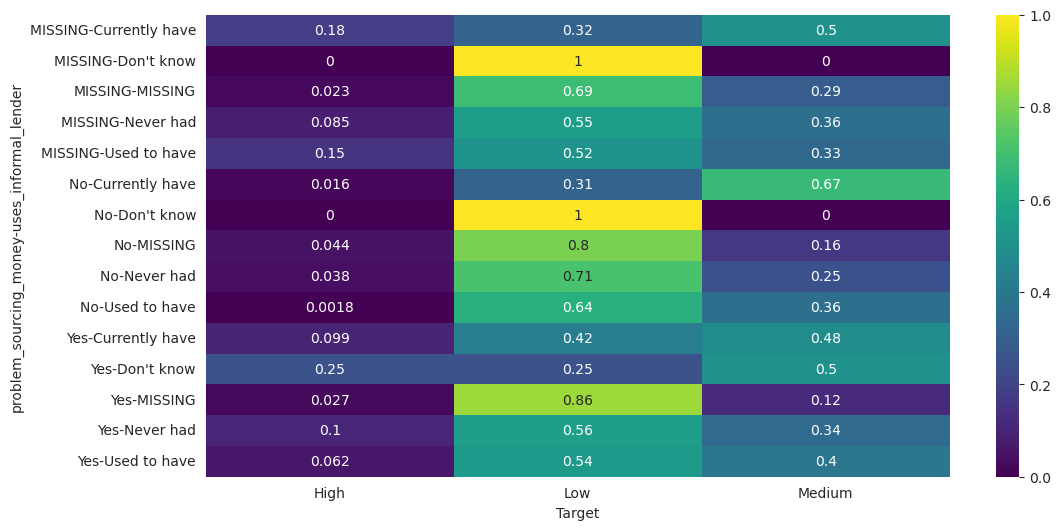

In [70]:
pivot = pd.crosstab(
    index=[train_data['problem_sourcing_money'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

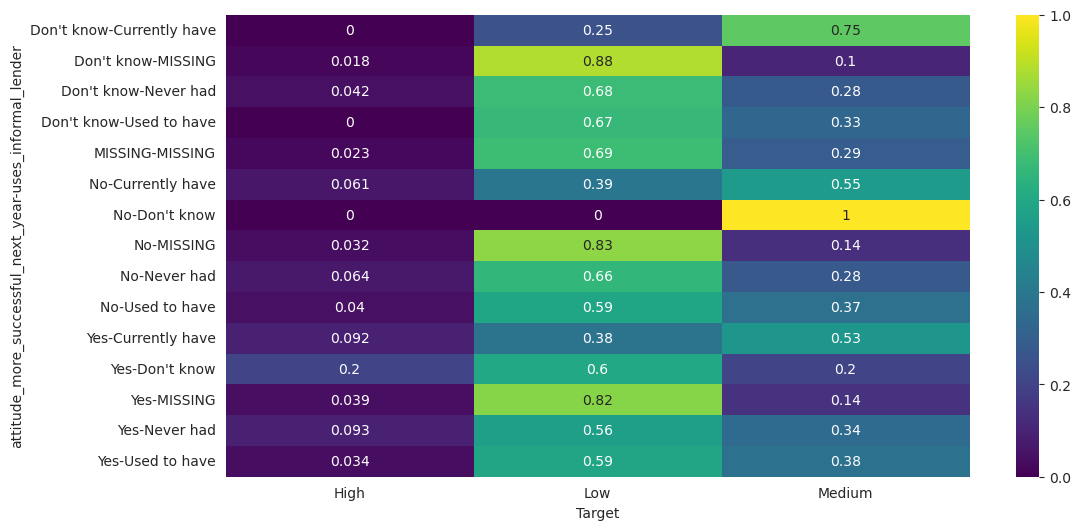

In [71]:
pivot = pd.crosstab(
    index=[train_data['attitude_more_successful_next_year'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners dont know attitude more successful next year and currently uses informal lender, they have a 75% of having medium HFI
- For owners whose attitude more successful next year is No and dont know if they use an informal lender, they have a 100% of having medium HFI

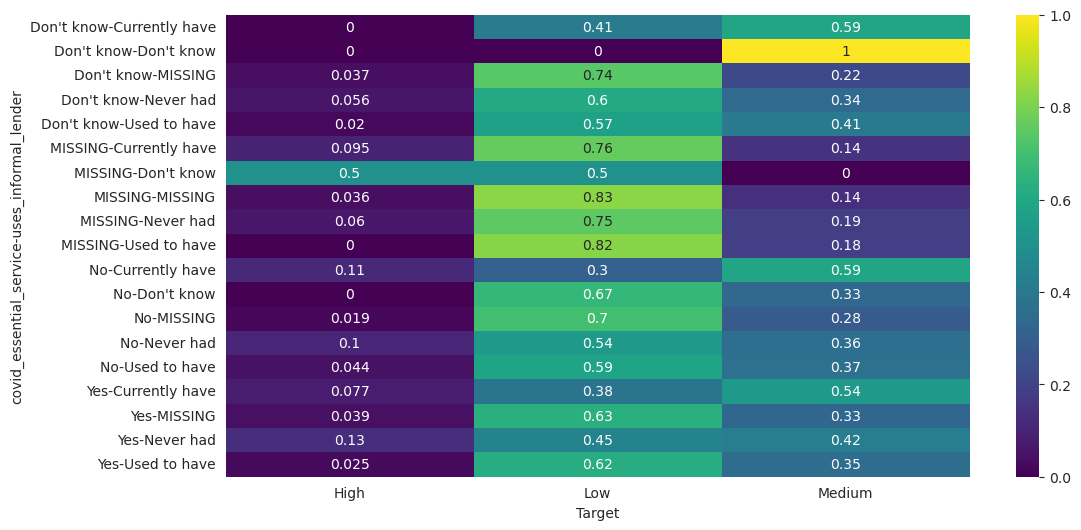

In [72]:
pivot = pd.crosstab(
    index=[train_data['covid_essential_service'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who dont know covid essential and dont know uses informal lender, they have a 100% of having medium HFI

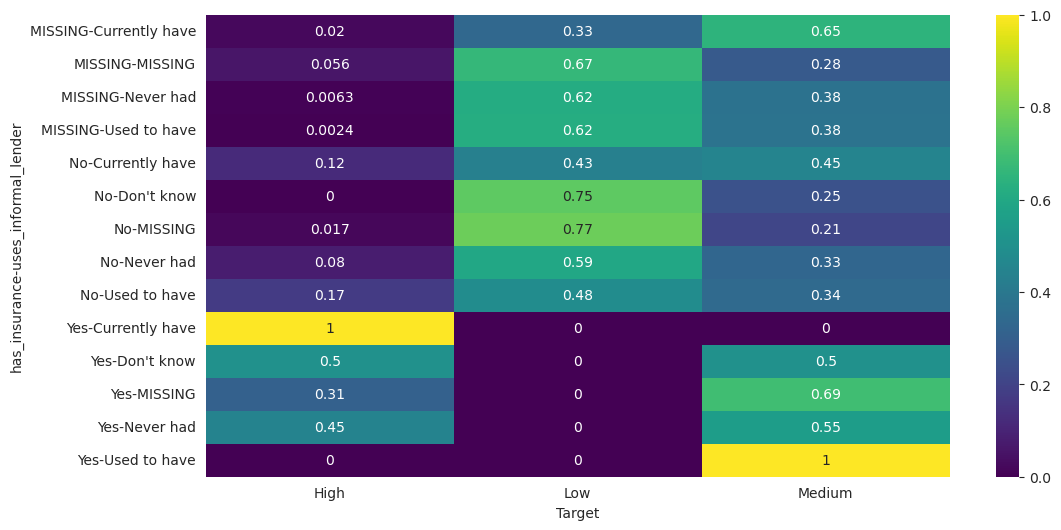

In [73]:
pivot = pd.crosstab(
    index=[train_data['has_insurance'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who have insurance and currently uses an informal lender, they have 100% of having high HFI
- For owners who have insurance and used to have an informal lender, they have 100% of having medium HFI

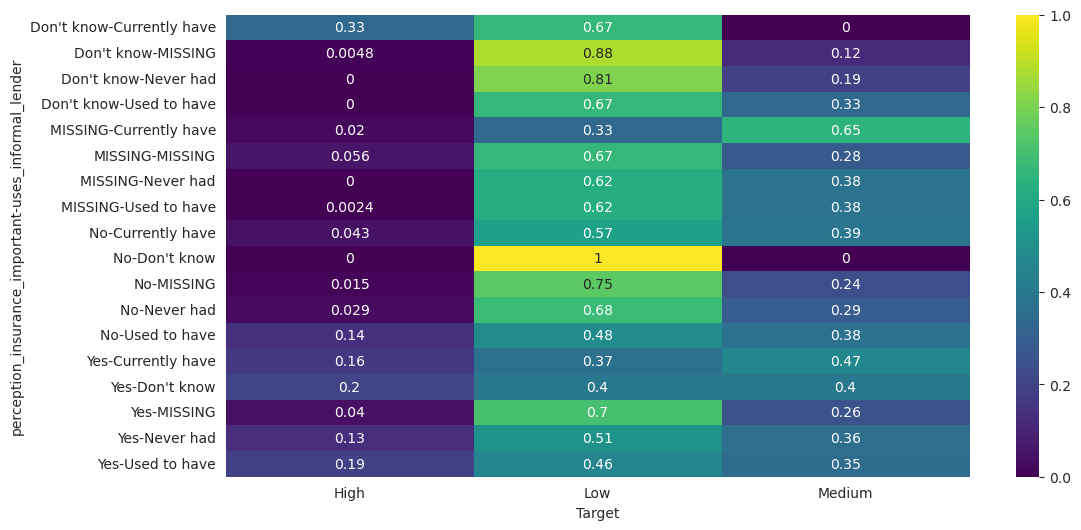

In [74]:
pivot = pd.crosstab(
    index=[train_data['perception_insurance_important'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners whose perception insurance important is dont know and never had an informal lender, they have a 81% chance of having low HFI
- For owners whose perception insurance important is No and dont know if they had an informal lender, they have a 100% chance of having low HFI

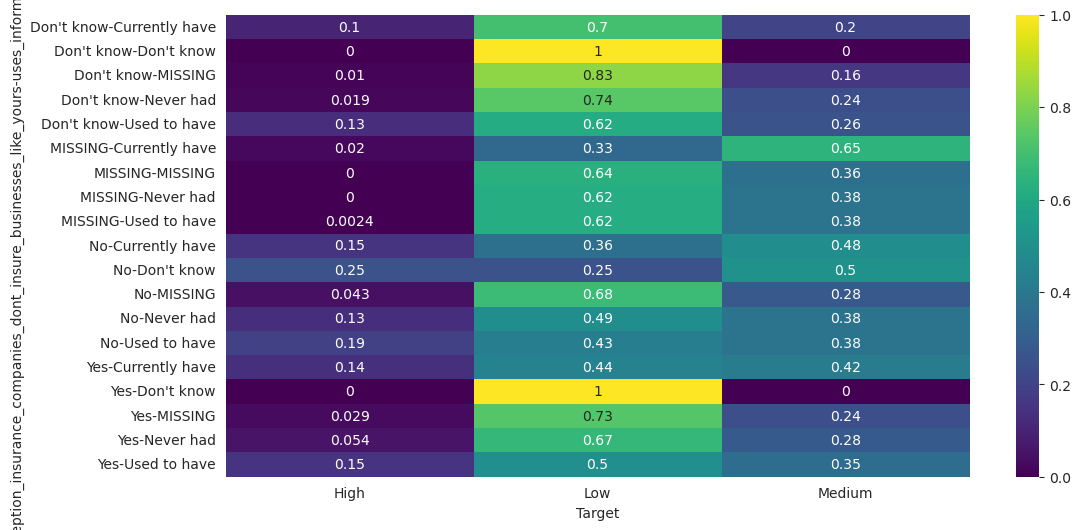

In [75]:
pivot = pd.crosstab(
    index=[train_data['perception_insurance_companies_dont_insure_businesses_like_yours'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners whose perception insurance companies dont insure bussiness like yours is dont know and dont know if they have an informal lender, thsy have 100% of having low HFI
- For owners whose perception insurance companies dont insure bussiness like yours is Yes and dont know if they have an informal lender, thsy have 100% of having low HFI

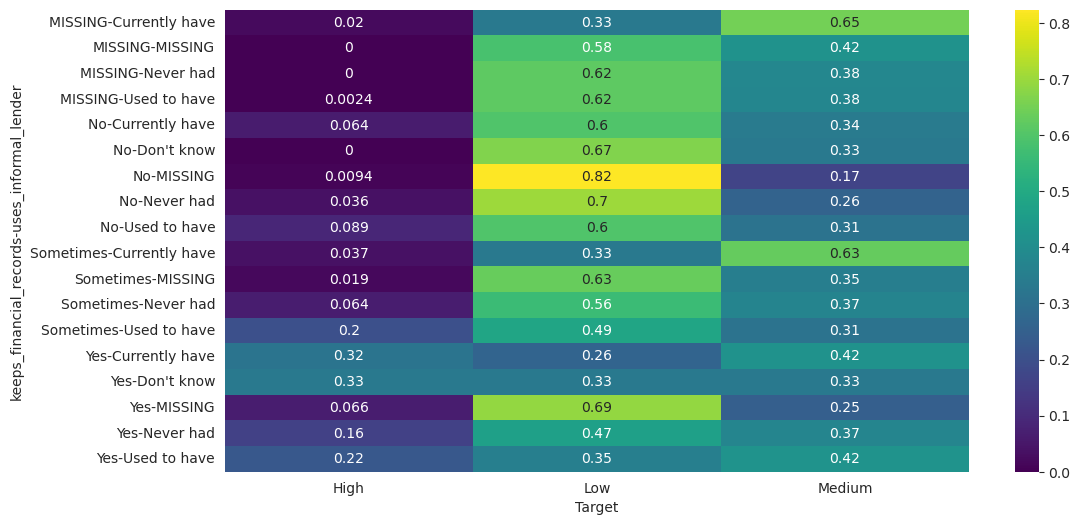

In [76]:
pivot = pd.crosstab(
    index=[train_data['keeps_financial_records'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

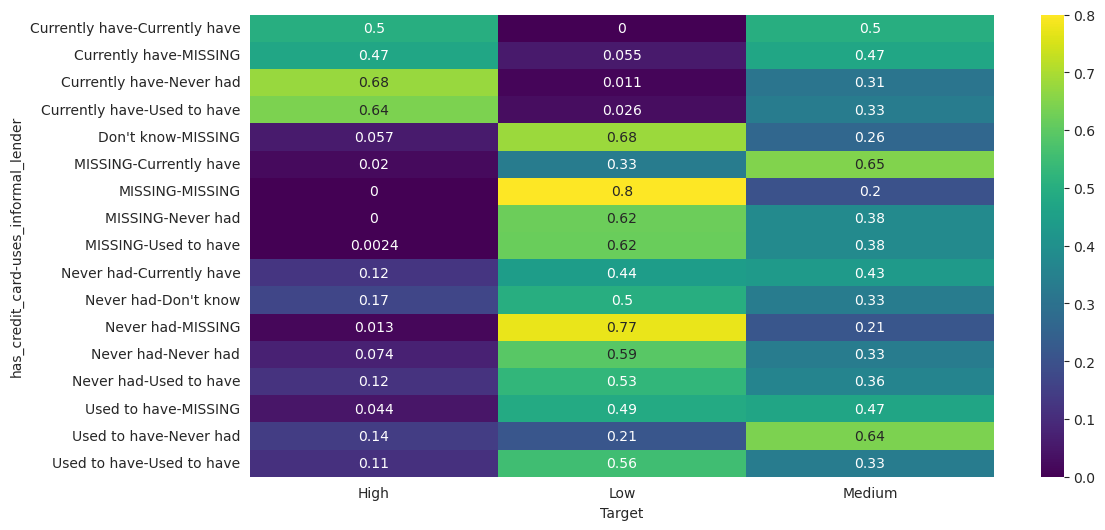

In [77]:
pivot = pd.crosstab(
    index=[train_data['has_credit_card'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

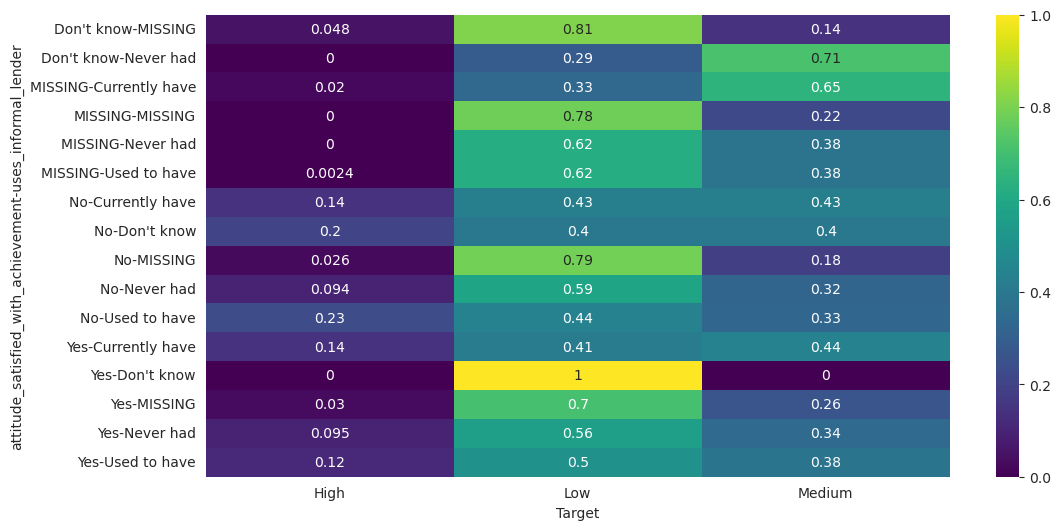

In [78]:
pivot = pd.crosstab(
    index=[train_data['attitude_satisfied_with_achievement'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

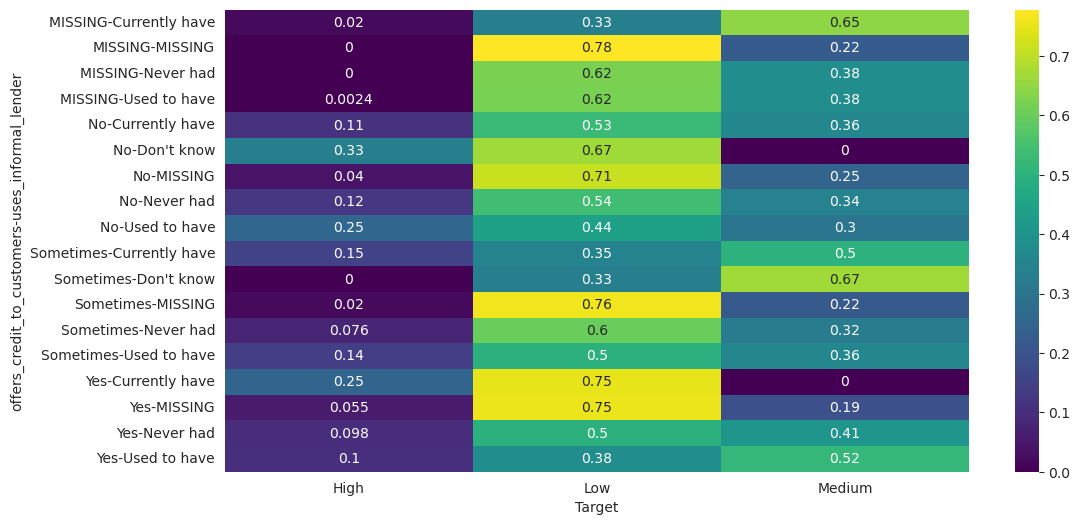

In [79]:
pivot = pd.crosstab(
    index=[train_data['offers_credit_to_customers'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

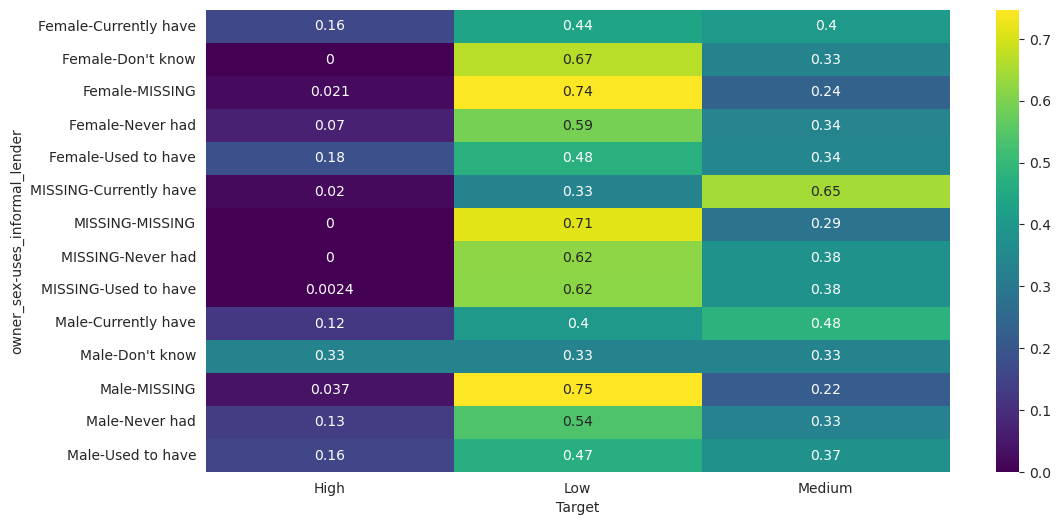

In [80]:
pivot = pd.crosstab(
    index=[train_data['owner_sex'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

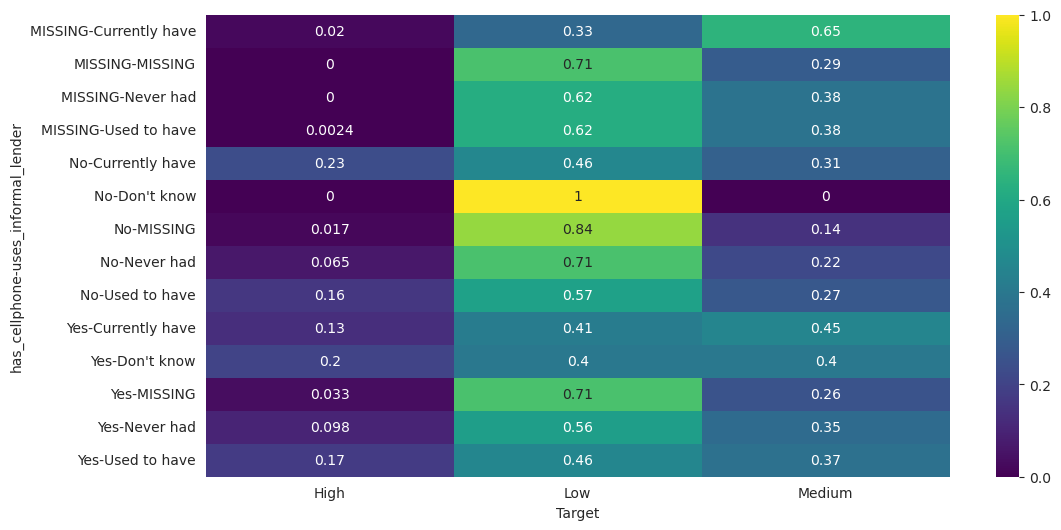

In [81]:
pivot = pd.crosstab(
    index=[train_data['has_cellphone'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

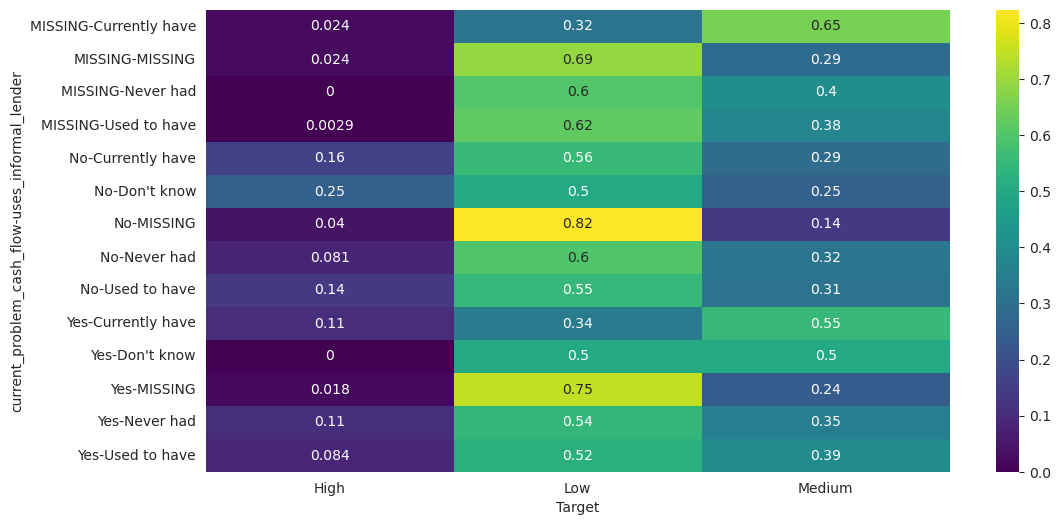

In [82]:
pivot = pd.crosstab(
    index=[train_data['current_problem_cash_flow'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

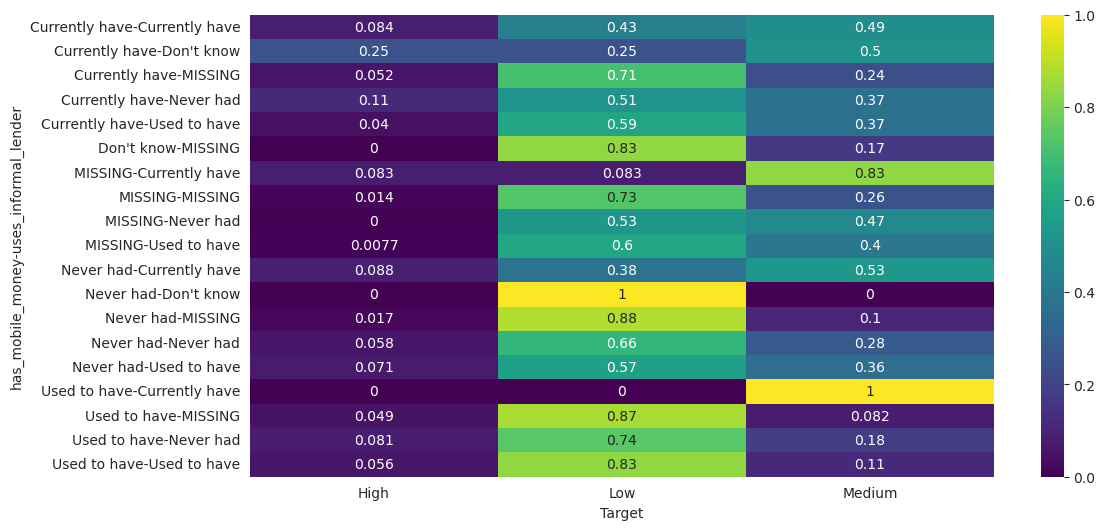

In [83]:
pivot = pd.crosstab(
    index=[train_data['has_mobile_money'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who used to have mobile money and currently have an informal lender, they have 100% of having medium HFI

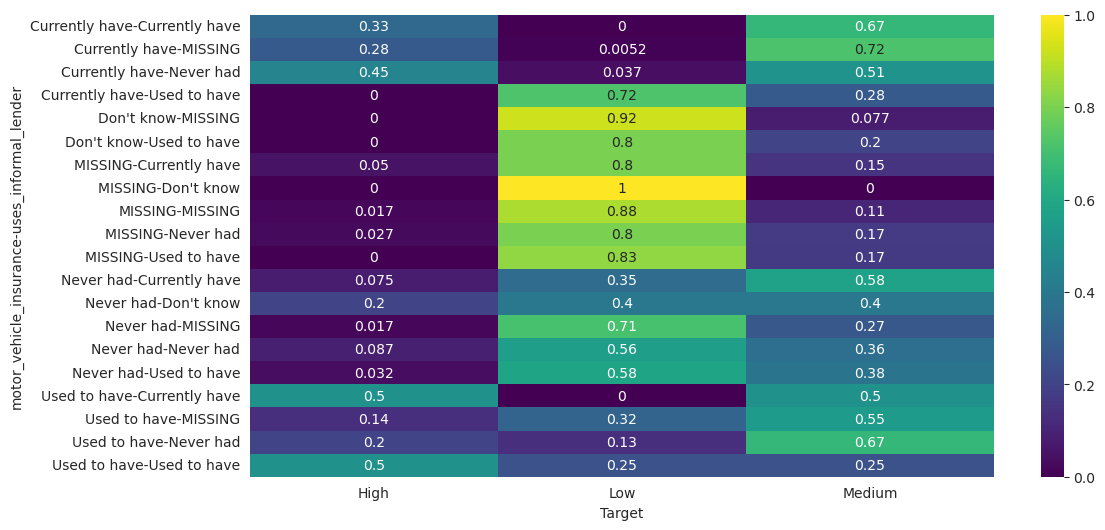

In [84]:
pivot = pd.crosstab(
    index=[train_data['motor_vehicle_insurance'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who used to have motor vehicle insurance and currently have an informal lender, they have a 50% of having high HFI. Also for owners who used to have motor vehicle insurance and used to have informal lender, they also have a 50% chance of having HFI

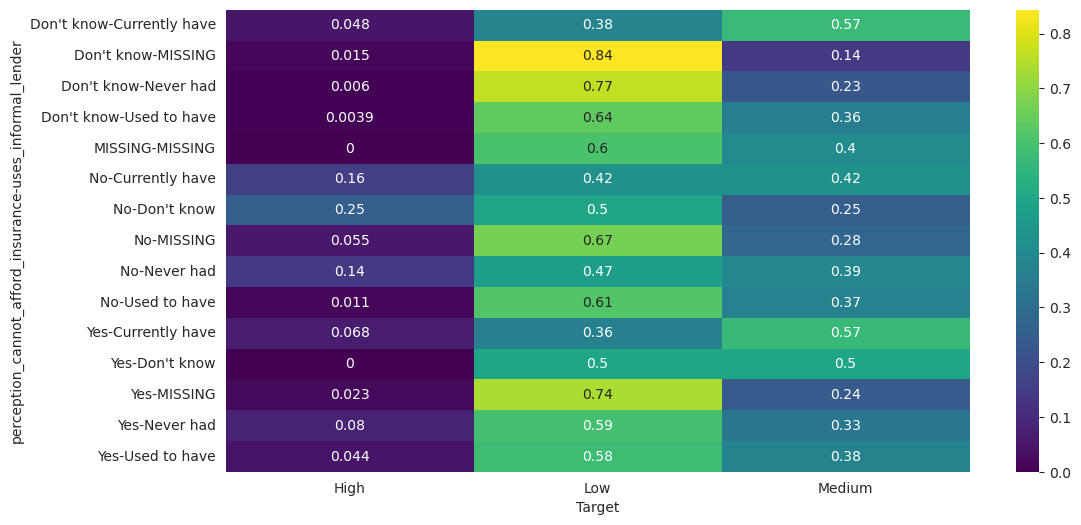

In [85]:
pivot = pd.crosstab(
    index=[train_data['perception_cannot_afford_insurance'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

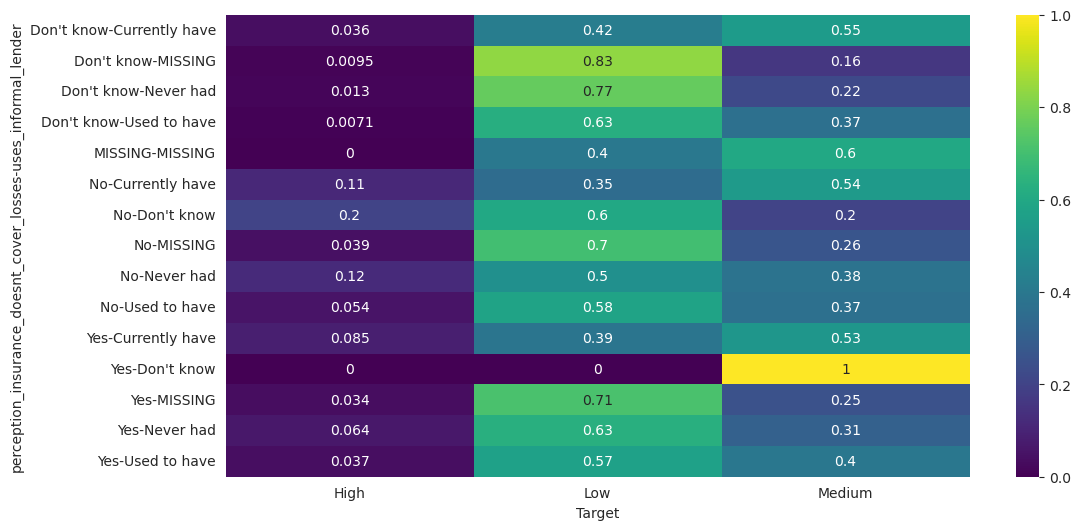

In [86]:
pivot = pd.crosstab(
    index=[train_data['perception_insurance_doesnt_cover_losses'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

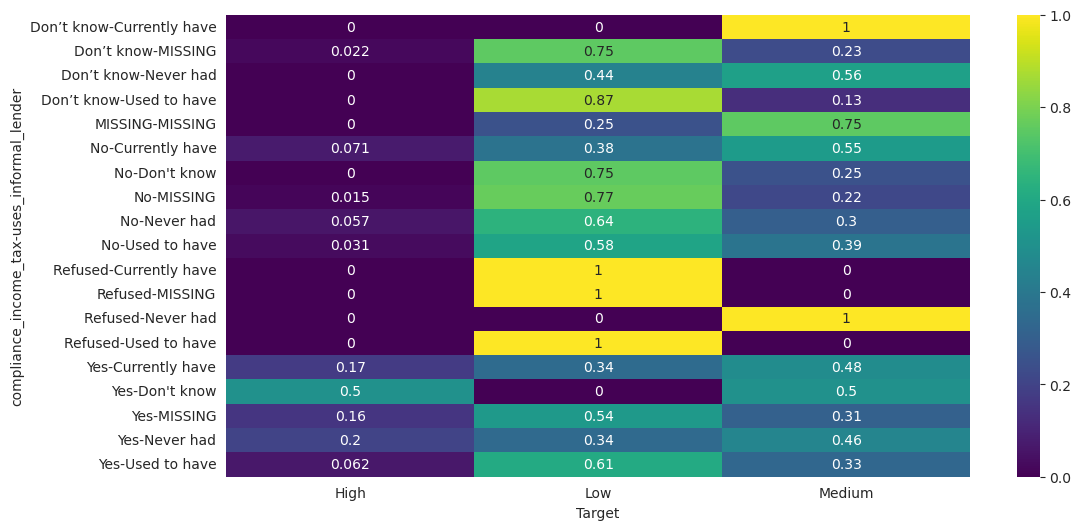

In [87]:
pivot = pd.crosstab(
    index=[train_data['compliance_income_tax'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who dont know compliance income tax and currently have an informal lender, they have 100% chance of having medium HFI
- For owners whose compliance income tax is Yes and never had an informal lender, they have 100% chance of having medium HFI

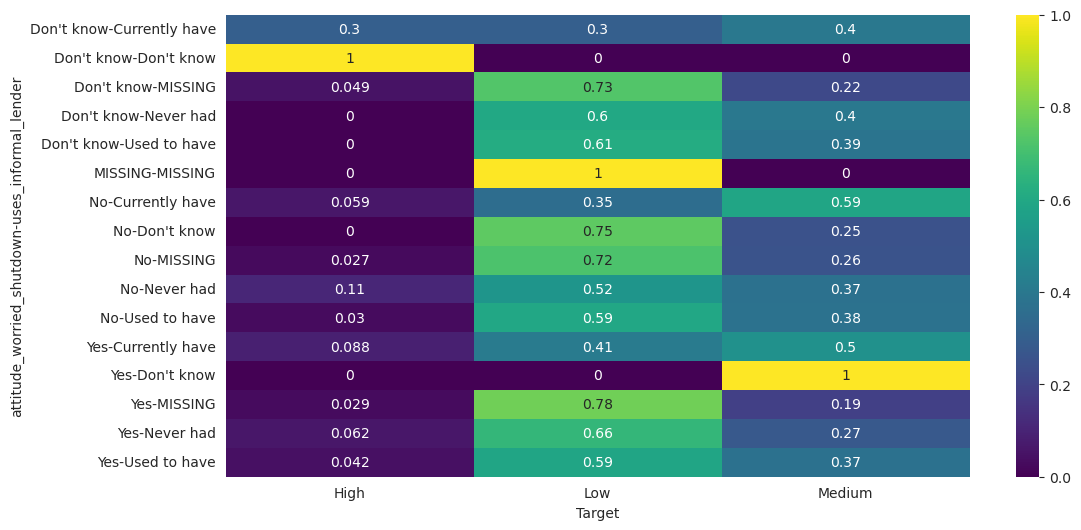

In [88]:
pivot = pd.crosstab(
    index=[train_data['attitude_worried_shutdown'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who dont know attitude worried shutdown and dont know uses informal lender have 100% of having high HFI
- For owners whose attitude worried shutdown is Yes and dont know uses unformal lender have 100% of having medium HFI

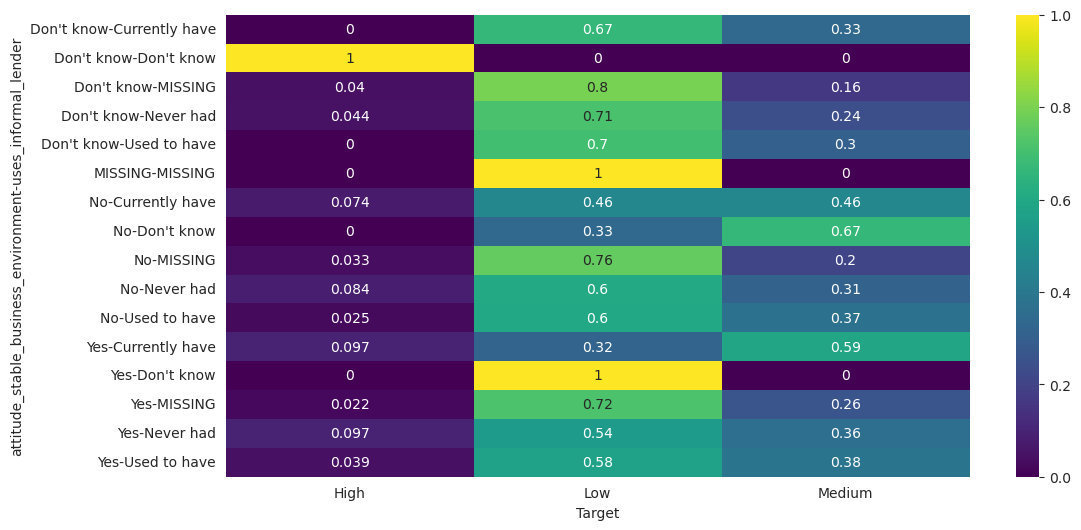

In [89]:
pivot = pd.crosstab(
    index=[train_data['attitude_stable_business_environment'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners who dont know attitude stable business environment and dont know uses informal lender, have 100% chance of having high HFI
- For owners whose attitude stable business environment is Yes and dont know uses informal lender, have 100% chance of having low HFI

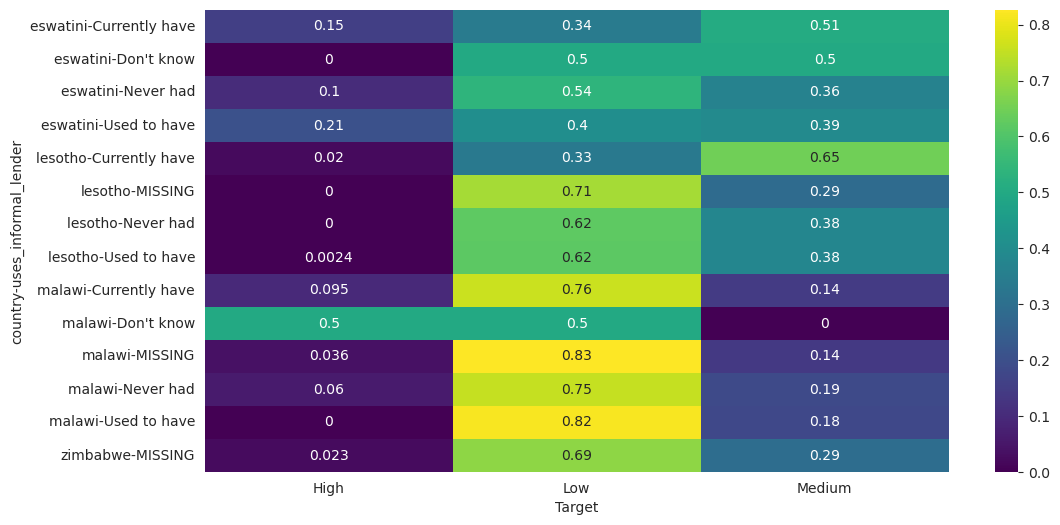

In [90]:
pivot = pd.crosstab(
    index=[train_data['country'], train_data['uses_informal_lender']],
    columns=train_data['Target'],
    normalize='index'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.show()

- For owners in malawi and used to have informal lenders, have 82% of having low HFI

In [91]:
numerical_cols

['owner_age',
 'personal_income',
 'business_expenses',
 'business_turnover',
 'business_age_years',
 'business_age_months']

# Feature Engineering

In [92]:
# Create copies to preserve original data
train_fe = train_data.copy()
test_fe = test_data.copy()


1️⃣ PROFIT MARGIN RATIO
----------------------------------------
Concept: How much profit does the business make relative to income?
Formula: (personal_income - business_expenses) / personal_income

✓ Created 'profit_margin' feature
  Train - Non-null values: 9618
  Test - Non-null values: 2405

Sample statistics:
count    9618.000000
mean       -0.211959
std         0.792522
min        -1.000000
25%        -1.000000
50%        -0.366238
75%         0.600000
max         1.000000
Name: profit_margin, dtype: float64

📊 Profit Margin by Target:
            mean    median       std
Target                              
High   -0.285465 -0.500000  0.758486
Low    -0.204207 -0.333333  0.797390
Medium -0.216889 -0.400000  0.786876


<Figure size 1000x500 with 0 Axes>

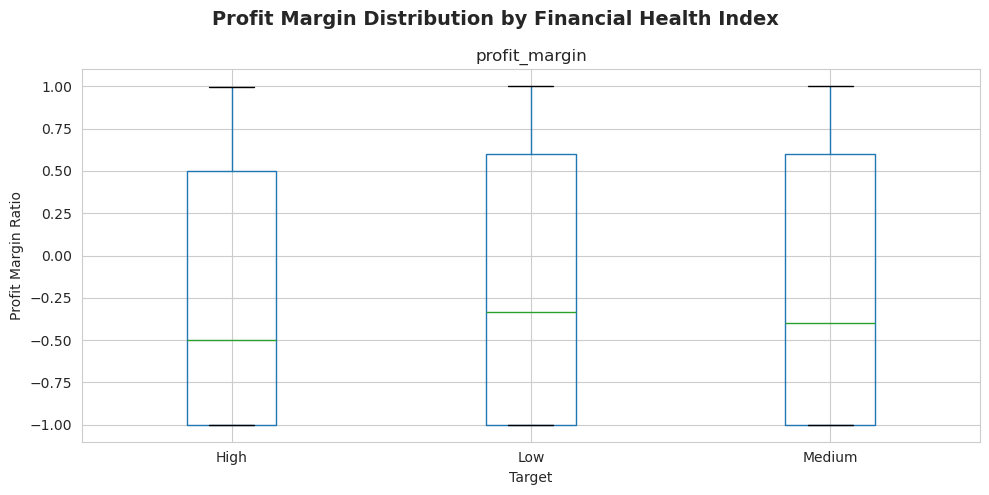

In [93]:
# ----------------------------------------
# Feature 1: Profit Margin Ratio
# ----------------------------------------
print("\n1️⃣ PROFIT MARGIN RATIO")
print("-" * 40)
print("Concept: How much profit does the business make relative to income?")
print("Formula: (personal_income - business_expenses) / personal_income")



def create_profit_margin(df):
    """
    Calculate profit margin ratio for each business.
    This indicates financial efficiency and sustainability.
    """
    profit_margin = []
    
    for _, row in df.iterrows():
        income = row.get('personal_income', 0)
        expenses = row.get('business_expenses', 0)

        if income == 0:
            margin = 0
        else:
            margin = (income - expenses) / income
            margin = max(-1, min(margin, 1))

        profit_margin.append(margin)
    
    return profit_margin

# create feature
train_fe['profit_margin'] = create_profit_margin(train_fe)
test_fe['profit_margin'] = create_profit_margin(test_fe)

print(f"\n✓ Created 'profit_margin' feature")
print(f"  Train - Non-null values: {train_fe['profit_margin'].notna().sum()}")
print(f"  Test - Non-null values: {test_fe['profit_margin'].notna().sum()}")
print("\nSample statistics:")
print(train_fe['profit_margin'].describe())


# Show relationship with target
if 'Target' in train_fe.columns:
    print("\n📊 Profit Margin by Target:")
    print(train_fe.groupby('Target')['profit_margin'].agg(['mean', 'median', 'std']))
    
    # Visualize
    plt.figure(figsize=(10, 5))
    train_fe.boxplot(column='profit_margin', by='Target', figsize=(10, 5))
    plt.suptitle('Profit Margin Distribution by Financial Health Index', 
                 fontsize=14, fontweight='bold')
    plt.xlabel('Target')
    plt.ylabel('Profit Margin Ratio')
    plt.tight_layout()
    plt.show()


2️⃣ FINANCIAL ACCESS SCORE
----------------------------------------
Concept: How many formal financial services does the business use?
Includes: bank accounts, debit cards, internet banking, loans, insurance

✓ Created 'financial_access_score' feature
  Train - Non-null values: 9618
  Test - Non-null values: 2405

Sample statistics:
count    9618.000000
mean        0.206560
std         0.207590
min         0.000000
25%         0.000000
50%         0.166667
75%         0.333333
max         1.000000
Name: financial_access_score, dtype: float64

📊 Financial Access Score by Target:
            mean    median       std
Target                              
High    0.448416  0.444444  0.189897
Low     0.147482  0.111111  0.193551
Medium  0.296286  0.277778  0.176975


<Figure size 1000x500 with 0 Axes>

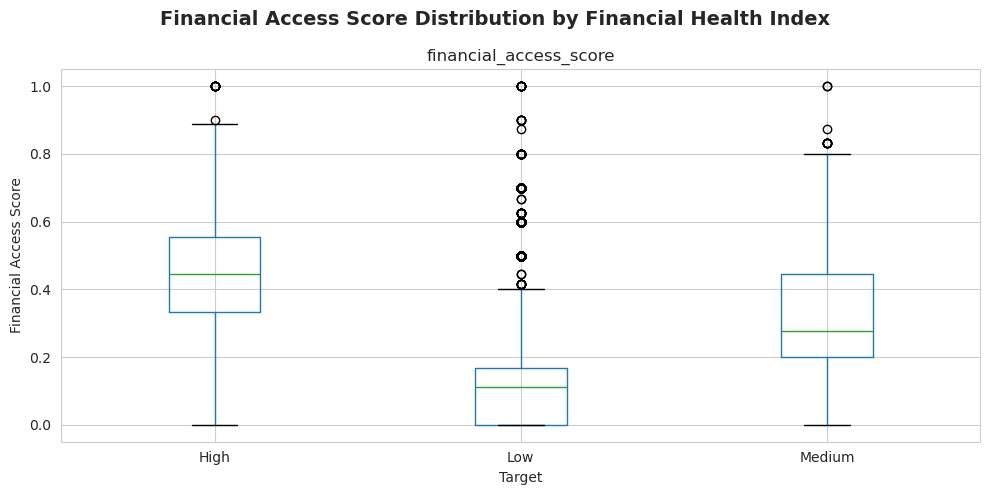

In [94]:
# ----------------------------------------
# Feature 2: Financial Access Score
# ----------------------------------------
print("\n2️⃣ FINANCIAL ACCESS SCORE")
print("-" * 40)
print("Concept: How many formal financial services does the business use?")
print("Includes: bank accounts, debit cards, internet banking, loans, insurance")


def create_financial_access_score(df):
    """
    Calculate a composite score of financial service access.
    Higher score = better access to formal financial services.
    """
    financial_features = [
        'motor_vehicle_insurance', 'has_loan_account', 'has_internet_banking', 'has_credit_card',
        'has_debit_card', 'medical_insurance', 'funeral_insurance', 'has_insurance', 'has_mobile_money'
    ]

    available_features = [c for c in financial_features if c in df.columns]

    scores = []

    for _, row in df[available_features].iterrows():
        score = 0
        answered = 0

        for value in row:
            if pd.isna(value) or value == "MISSING":
                continue

            answered += 1
            v = str(value).strip().lower()

            if v in ["yes", "have now", "currently have"]:
                score += 1
            elif v in ["used to have", "used to have but don't have no"]:
                score += 0.5

        # Replace NaN with 0.0 (no access)
        scores.append(score / answered if answered > 0 else 0.0)

    return pd.Series(scores, index=df.index)


train_fe['financial_access_score'] = create_financial_access_score(train_fe)
test_fe['financial_access_score'] = create_financial_access_score(test_fe)

print(f"\n✓ Created 'financial_access_score' feature")
print(f"  Train - Non-null values: {train_fe['financial_access_score'].notna().sum()}")
print(f"  Test - Non-null values: {test_fe['financial_access_score'].notna().sum()}")
print("\nSample statistics:")
print(train_fe['financial_access_score'].describe())

# Show relationship with target
if 'Target' in train_fe.columns:
    print("\n📊 Financial Access Score by Target:")
    print(train_fe.groupby('Target')['financial_access_score'].agg(['mean', 'median', 'std']))
    
    # Visualize
    plt.figure(figsize=(10, 5))
    train_fe.boxplot(column='financial_access_score', by='Target', figsize=(10, 5))
    plt.suptitle('Financial Access Score Distribution by Financial Health Index', 
                 fontsize=14, fontweight='bold')
    plt.xlabel('Target')
    plt.ylabel('Financial Access Score')
    plt.tight_layout()
    plt.show()


In [95]:
# ----------------------------------------
# Feature 3: Management Quality Score (FIXED)
# ----------------------------------------

def create_management_score(df, columns_list=None):
    """
    Composite Management Quality Score.
    Higher score = better management practices.
    Normalized between 0 and 1.

    columns_list: list of tuples
      (column_name, max_score_for_that_column)
    """

    if columns_list is None:
        columns_list = [
            ('keeps_financial_records', 2),
            ('offers_credit_to_customers', 1.5),
            ('future_risk_theft_stock', 1)
        ]

    scores = []

    for _, row in df.iterrows():
        score = 0
        max_score = 0

        for col_name, col_max in columns_list:
            val = row.get(col_name)

            # skip missing values
            if pd.isna(val) or val == 'MISSING':
                continue

            max_score += col_max

            # scoring rules
            if val == 'Yes':
                score += col_max
            elif val == 'Sometimes':
                score += col_max / 2

        # normalize
        if max_score > 0:
            final_score = score / max_score
        else:
            final_score = 0.4

        scores.append(final_score)

    return pd.Series(scores, index=df.index)


train_fe['management_score'] = create_management_score(train_fe)
test_fe['management_score'] = create_management_score(test_fe)

print("✓ Created 'management_score'")
print("Train non-null:", train_fe['management_score'].notna().sum())
print("Test non-null:", test_fe['management_score'].notna().sum())

train_fe['management_score'].describe()

train_fe.groupby('Target')['management_score'].agg(['mean', 'median', 'std'])

✓ Created 'management_score'
Train non-null: 9618
Test non-null: 2405


,mean,median,std
Target,,,
High,0.553438,0.571429,0.228328
Low,0.408440,0.400000,0.266950
Medium,0.481618,0.400000,0.258970


In [96]:
# ----------------------------------------
# Feature 4: Debt & Leverage Score (FIXED)
# ----------------------------------------

def create_debt_leverage_score(df, columns_list=None):
    """
    Debt & Leverage Score.
    Higher score = lower debt risk (healthier leverage).
    Normalized between 0 and 1.
    
    columns_list = [
        (col_name, max_penalty, mapping_dict)
    ]
    """

    if columns_list is None:
        columns_list = [
            ('has_loan_account', 1, {'Yes': 0.5, 'Currently have': 0.5, 'Have now': 0.5, 'Used to have': 0.25}),
            ('uses_friends_family_savings', 1.5, {'Yes': 1.5}),
            ('uses_informal_lender', 2, {'Yes': 2})
        ]

    scores = []

    for _, row in df.iterrows():
        penalty = 0
        max_penalty = 0

        for col_name, max_pen, mapping in columns_list:
            val = row.get(col_name)

            if pd.isna(val) or val == 'MISSING':
                continue

            max_penalty += max_pen
            penalty += mapping.get(val, 0)

        score = 1 - (penalty / max_penalty) if max_penalty > 0 else 1.0
        scores.append(score)

    return pd.Series(scores, index=df.index)


train_fe['debt_leverage_score'] = create_debt_leverage_score(train_fe)
test_fe['debt_leverage_score'] = create_debt_leverage_score(test_fe)

print("✓ Created 'debt_leverage_score'")
print("Train non-null:", train_fe['debt_leverage_score'].notna().sum())
print("Test non-null:", test_fe['debt_leverage_score'].notna().sum())

train_fe.groupby('Target')['debt_leverage_score'].mean()


✓ Created 'debt_leverage_score'
Train non-null: 9618
Test non-null: 2405


Target
High      0.934220
Low       0.993831
Medium    0.989224
Name: debt_leverage_score, dtype: float64

In [97]:
# ----------------------------------------
# Feature 5: Cash Flow / Liquidity Score
# ----------------------------------------

def create_liquidity_stress_score(df, columns_list=None):
    """
    Cash Flow / Liquidity Score.
    Higher score = lower liquidity stress (more cash stress).
    Normalized between 0 and 1.
    
    columns_list = [
        (col_name, max_penalty)
    ]
    """

    if columns_list is None:
        columns_list = [
            ('current_problem_cash_flow', 2),
            ('problem_sourcing_money', 1.5)
        ]

    scores = []

    for _, row in df.iterrows():
        penalty = 0
        max_penalty = 0

        for col_name, max_pen in columns_list:
            val = row.get(col_name)

            if pd.isna(val) or val == 'MISSING':
                continue

            max_penalty += max_pen
            if val == 'Yes':
                penalty += max_pen

        score = 1 - (penalty / max_penalty) if max_penalty > 0 else np.nan
        scores.append(score)

    return pd.Series(scores, index=df.index)

train_fe['liquidity_stress_score'] = create_liquidity_stress_score(train_fe).fillna(0.5)
test_fe['liquidity_stress_score'] = create_liquidity_stress_score(test_fe).fillna(0.5)

print("✓ Created 'liquidity_stress_score'")
print("Train non-null:", train_fe['liquidity_stress_score'].notna().sum())
print("Test non-null:", test_fe['liquidity_stress_score'].notna().sum())

train_fe.groupby('Target')['liquidity_stress_score'].mean()

✓ Created 'liquidity_stress_score'
Train non-null: 9618
Test non-null: 2405


Target
High      0.432067
Low       0.528890
Medium    0.479055
Name: liquidity_stress_score, dtype: float64

In [98]:
# ----------------------------------------
# Feature 6: Inventory Accounts Receivable Score
# ----------------------------------------

def create_inventory_ar_score(df, columns_list=None):
    """
    Inventory & Accounts Receivable Risk Score
    Higher score = better AR & inventory management
    Normalized between 0 and 1
    """

    if columns_list is None:
        columns_list = [
            'profit_margin',
            'business_turnover',
            'business_expenses',
            'future_risk_theft_stock',
            'keeps_financial_records'
        ]

    scores = []

    for _, row in df.iterrows():
        score = 0
        max_score = 0

        # 1️⃣ Profit Margin (max = 2)
        if 'profit_margin' in columns_list:
            val = row.get('profit_margin')
            if pd.notna(val):
                max_score += 2
                if val > 0:
                    score += 2
                elif val == 0:
                    score += 1

        # 2️⃣ Turnover vs Expenses (max = 2)
        if 'business_turnover' in columns_list and 'business_expenses' in columns_list:
            t = row.get('business_turnover')
            e = row.get('business_expenses')

            if pd.notna(t) and pd.notna(e):
                max_score += 2
                if t > e:
                    score += 2
                elif t == e:
                    score += 1

        # 3️⃣ Theft/Stock risk (max = 1.5)
        if 'future_risk_theft_stock' in columns_list:
            val = row.get('future_risk_theft_stock')
            if pd.notna(val) and val != 'MISSING':
                max_score += 1.5
                if val == 'Yes':
                    score += 0.5

        # 4️⃣ Record keeping (max = 1.5)
        if 'keeps_financial_records' in columns_list:
            val = row.get('keeps_financial_records')
            if pd.notna(val) and val != 'MISSING':
                max_score += 1.5
                if val == 'Yes':
                    score += 1.5
                elif val == 'Sometimes':
                    score += 0.75

        # normalize
        final_score = score / max_score if max_score > 0 else 0.5
        scores.append(final_score)

    return pd.Series(scores, index=df.index)

train_fe['inventory_ar_score'] = create_inventory_ar_score(train_fe).fillna(0.5)
test_fe['inventory_ar_score'] = create_inventory_ar_score(test_fe).fillna(0.5)

print("✓ Created 'inventory_ar_score'")
print("Train non-null:", train_fe['inventory_ar_score'].notna().sum())
print("Test non-null:", test_fe['inventory_ar_score'].notna().sum())

train_fe.groupby('Target')['inventory_ar_score'].mean()

✓ Created 'inventory_ar_score'
Train non-null: 9618
Test non-null: 2405


Target
High      0.659664
Low       0.549627
Medium    0.613901
Name: inventory_ar_score, dtype: float64

In [99]:
# ----------------------------------------------------------
# Feature 7: Confidence Score (Attitude and Perceptions)
# ----------------------------------------------------------

def create_confidence_score(df):
    """
    Business Confidence Score based on attitudes and perceptions.
    Higher score = more confident / optimistic owner.
    """

    pos_cols = [
        'attitude_stable_business_environment',
        'attitude_satisfied_with_achievement',
        'attitude_more_successful_next_year'
    ]

    neg_cols = [
        'attitude_worried_shutdown',
        'perception_insurance_doesnt_cover_losses',
        'perception_cannot_afford_insurance',
        'perception_insurance_companies_dont_insure_businesses_like_yours'
    ]

    scores = []

    for _, row in df.iterrows():
        score = 0
        max_score = 0

        for col in pos_cols:
            val = row.get(col)
            if pd.isna(val) or val == 'MISSING':
                continue
            max_score += 1
            if val == 'Yes':
                score += 1
            elif val == 'No':
                score -= 1

        for col in neg_cols:
            val = row.get(col)
            if pd.isna(val) or val == 'MISSING':
                continue
            max_score += 1
            if val == 'Yes':
                score -= 1   # NEGATIVE impact
            elif val == 'No':
                score += 1   # POSITIVE impact

        # normalize
        final_score = (score + max_score) / (2 * max_score) if max_score else 0.5
        scores.append(final_score)

    return pd.Series(scores, index=df.index)

train_fe['confidence_score'] = create_confidence_score(train_fe).fillna(0.5)
test_fe['confidence_score'] = create_confidence_score(test_fe).fillna(0.5)

print("✓ Created 'confidence_score'")
print("Train non-null:", train_fe['confidence_score'].notna().sum())
print("Test non-null:", test_fe['confidence_score'].notna().sum())

train_fe.groupby('Target')['confidence_score'].mean()

✓ Created 'confidence_score'
Train non-null: 9618
Test non-null: 2405


Target
High      0.656342
Low       0.574290
Medium    0.622122
Name: confidence_score, dtype: float64

In [100]:
# ----------------------------------------------------------
# Feature 8: Cost efficiency score
# ----------------------------------------------------------

def create_cost_efficiency_score(df,
                                 cost_cols=None,
                                 stress_cols=None,
                                 discipline_cols=None):
    """
    Cost Efficiency & Expense Pressure Score
    Higher score = better cost control and efficiency
    Normalized between 0 and 1
    """

    if cost_cols is None:
        cost_cols = ['expense_ratio', 'net_profit', 'profit_margin']

    if stress_cols is None:
        stress_cols = ['current_problem_cash_flow', 'problem_sourcing_money']

    if discipline_cols is None:
        discipline_cols = ['keeps_financial_records', 'management_score']

    scores = []

    for _, row in df.iterrows():
        score = 0
        max_score = 0

        # 1️⃣ Cost structure (numeric)
        for col in cost_cols:
            val = row.get(col)
            if pd.isna(val):
                continue

            max_score += 1

            if col == 'expense_ratio':
                if val < 0.5:
                    score += 1
                elif val < 0.75:
                    score += 0.5

            elif col in ['net_profit', 'profit_margin']:
                if val > 0:
                    score += 1
                elif val == 0:
                    score += 0.5

        # 2️⃣ Cost stress (binary, negative if Yes)
        for col in stress_cols:
            val = row.get(col)
            if pd.isna(val) or val == 'MISSING':
                continue

            max_score += 1
            if val == 'No':
                score += 1
            elif val == 'Yes':
                score += 0

        # 3️⃣ Cost discipline
        for col in discipline_cols:
            val = row.get(col)
            if pd.isna(val) or val == 'MISSING':
                continue

            max_score += 1

            if col == 'keeps_financial_records':
                if val == 'Yes':
                    score += 1
                elif val == 'Sometimes':
                    score += 0.5

            elif col == 'management_score':
                score += val  # already 0–1

        final_score = score / max_score if max_score > 0 else 0.5
        scores.append(final_score)

    return pd.Series(scores, index=df.index)

train_fe['cost_efficiency_score'] = create_cost_efficiency_score(train_fe)
test_fe['cost_efficiency_score'] = create_cost_efficiency_score(test_fe)

print("✓ Created 'cost_efficiency_score'")
print("Train non-null:", train_fe['cost_efficiency_score'].notna().sum())
print("Test non-null:", test_fe['cost_efficiency_score'].notna().sum())


train_fe.groupby('Target')['cost_efficiency_score'].mean()

✓ Created 'cost_efficiency_score'
Train non-null: 9618
Test non-null: 2405


Target
High      0.503622
Low       0.438782
Medium    0.467733
Name: cost_efficiency_score, dtype: float64

In [101]:
# ==================================================
# NEW FEATURES BASED ON Target Vs Feature analysis
# ==================================================

# Aggregate missingness
financial_missing_cols = [
  'has_insurance','medical_insurance','funeral_insurance','has_debit_card',
  'has_credit_card','has_internet_banking','has_loan_account',
  'uses_informal_lender','uses_friends_family_savings'
]
train_fe['missing_financial_info_count'] = train_fe[financial_missing_cols].isin(['MISSING', np.nan]).sum(axis=1)
test_fe['missing_financial_info_count']  = test_fe[financial_missing_cols].isin(['MISSING', np.nan]).sum(axis=1)

# Insurance strength / exposure
train_fe['insurance_count'] = (
    train_fe['has_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0) +
    train_fe['medical_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0) +
    train_fe['funeral_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0) +
    train_fe['motor_vehicle_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0)
)
test_fe['insurance_count'] = (
    test_fe['has_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0) +
    test_fe['medical_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0) +
    test_fe['funeral_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0) +
    test_fe['motor_vehicle_insurance'].map({'Yes':1,'No':0,'MISSING':0}).fillna(0)
)

# Financial exclusion score (compress many columns)
access_cols = ['has_debit_card','has_credit_card','has_internet_banking','has_loan_account','has_insurance','has_mobile_money']
train_fe['financial_exclusion_score'] = (train_fe[access_cols].applymap(lambda v: 1 if str(v).strip()=='Yes' else 0).sum(axis=1) / len(access_cols))
test_fe['financial_exclusion_score']  = (test_fe[access_cols].applymap(lambda v: 1 if str(v).strip()=='Yes' else 0).sum(axis=1) / len(access_cols))


In [102]:
# ==================================================
# NEW FEATURES BASED ON Multivariate analysis
# ==================================================

def norm(x):
    if pd.isna(x):
        return "missing"
    return str(x).strip().lower()


def add_interaction_features(df):
    df = df.copy()

    df["country_informal"] = df["country"] + "_" + df["uses_informal_lender"]
    df["stable_env_informal"] = df["attitude_stable_business_environment"] + "_" + df["uses_informal_lender"]
    df["shutdown_worry_informal"] = df["attitude_worried_shutdown"] + "_" + df["uses_informal_lender"]
    df["insurance_informal"] = df["has_insurance"] + "_" + df["uses_informal_lender"]
    df["digital_informal"] = df["has_mobile_money"] + "_" + df["has_internet_banking"] + "_" + df["uses_informal_lender"]
    df["loan_informal"] = df["has_loan_account"] + "_" + df["uses_informal_lender"]
    df["social_informal"] = df["uses_friends_family_savings"] + "_" + df["uses_informal_lender"]

    df["formal_informal_conflict"] = (
        (df["has_insurance"] == "Yes") &
        (df["uses_informal_lender"] == "Currently have")
    ).astype(int)

    df["dual_uncertainty_flag"] = (
        (df["uses_informal_lender"].isin(["Don't know", "MISSING"])) &
        (
            (df["attitude_stable_business_environment"] == "Don't know") |
            (df["attitude_worried_shutdown"] == "Don't know")
        )
    ).astype(int)

    df["digital_informal_mismatch"] = (
        (df["has_mobile_money"] == "Yes") &
        (df["uses_informal_lender"].isin(["Currently have", "Used to have"]))
    ).astype(int)

    df["social_dependency"] = (
        (df["uses_friends_family_savings"] == "Yes") &
        (df["uses_informal_lender"].isin(["Currently have", "Used to have"]))
    ).astype(int)

    stress_cols = [
        "current_problem_cash_flow",
        "problem_sourcing_money",
        "attitude_worried_shutdown",
        "keeps_financial_records",
        "has_insurance"
    ]

    df["informal_stress_score"] = 0
    for col in stress_cols:
        df["informal_stress_score"] += (
            (df[col] == "Yes") | (df[col] == "No")
        ).astype(int)

    df["informal_stress_score"] *= (
        df["uses_informal_lender"].isin(["Currently have", "Used to have"])
    ).astype(int)

    return df

#train_fe = add_interaction_features(train_fe)
#test_fe = add_interaction_features(train_fe)

In [103]:
# =======================================
# NEW FEATURES BASED ON TOP IMPORTANCE
# =======================================

# 1) Expense Ratio (expenses / turnover)
train_fe['expense_ratio'] = train_fe['business_expenses'] / train_fe['business_turnover']
test_fe['expense_ratio'] = test_fe['business_expenses'] / test_fe['business_turnover']

train_fe['expense_ratio_missing'] = train_fe['expense_ratio'].isna().astype(int)
test_fe['expense_ratio_missing'] = test_fe['expense_ratio'].isna().astype(int)


# 2) Net Profit (income - expenses)
train_fe['net_profit'] = train_fe['personal_income'] - train_fe['business_expenses']
test_fe['net_profit'] = test_fe['personal_income'] - test_fe['business_expenses']

train_fe['net_profit_missing'] = train_fe['net_profit'].isna().astype(int)
test_fe['net_profit_missing'] = test_fe['net_profit'].isna().astype(int)


# 3) Credit Access Index
train_fe['credit_access_index'] = (
    train_fe['financial_access_score'] *
    train_fe['has_credit_card'].map({'Yes':1, 'No':0, 'MISSING':0})
)
test_fe['credit_access_index'] = (
    test_fe['financial_access_score'] *
    test_fe['has_credit_card'].map({'Yes':1, 'No':0, 'MISSING':0})
)

train_fe['credit_access_index_missing'] = train_fe['credit_access_index'].isna().astype(int)
test_fe['credit_access_index_missing'] = test_fe['credit_access_index'].isna().astype(int)


# 4) Debt Stress (1 - debt_leverage_score)
train_fe['debt_stress'] = 1 - train_fe['debt_leverage_score']
test_fe['debt_stress'] = 1 - test_fe['debt_leverage_score']

train_fe['debt_stress_missing'] = train_fe['debt_stress'].isna().astype(int)
test_fe['debt_stress_missing'] = test_fe['debt_stress'].isna().astype(int)


# 5) Management * Liquidity interaction
train_fe['mgmt_liquidity'] = train_fe['management_score'] * (1 - train_fe['liquidity_stress_score'])
test_fe['mgmt_liquidity'] = test_fe['management_score'] * (1 - test_fe['liquidity_stress_score'])

train_fe['mgmt_liquidity_missing'] = train_fe['mgmt_liquidity'].isna().astype(int)
test_fe['mgmt_liquidity_missing'] = test_fe['mgmt_liquidity'].isna().astype(int)


# 6) Insurance Awareness Score
train_fe['insurance_awareness'] = (
    train_fe['has_insurance'].map({'Yes':1, 'No':0, 'MISSING':0}) +
    train_fe['perception_insurance_doesnt_cover_losses'].map({'Yes':1, 'No':0, 'MISSING':0}) +
    train_fe['perception_cannot_afford_insurance'].map({'Yes':1, 'No':0, 'MISSING':0})
)

test_fe['insurance_awareness'] = (
    test_fe['has_insurance'].map({'Yes':1, 'No':0, 'MISSING':0}) +
    test_fe['perception_insurance_doesnt_cover_losses'].map({'Yes':1, 'No':0, 'MISSING':0}) +
    test_fe['perception_cannot_afford_insurance'].map({'Yes':1, 'No':0, 'MISSING':0})
)

train_fe['insurance_awareness_missing'] = train_fe['insurance_awareness'].isna().astype(int)
test_fe['insurance_awareness_missing'] = test_fe['insurance_awareness'].isna().astype(int)


# 7) Owner Age vs Business Age ratio
train_fe['owner_age_to_business_age'] = train_fe['owner_age'] / (train_fe['business_age_years'] + 0.1)
test_fe['owner_age_to_business_age'] = test_fe['owner_age'] / (test_fe['business_age_years'] + 0.1)

train_fe['owner_age_to_business_age_missing'] = train_fe['owner_age_to_business_age'].isna().astype(int)
test_fe['owner_age_to_business_age_missing'] = test_fe['owner_age_to_business_age'].isna().astype(int)


# 8) Financial Stress (liquidity + debt stress)
train_fe['financial_stress'] = train_fe['liquidity_stress_score'] + (1 - train_fe['debt_leverage_score'])
test_fe['financial_stress'] = test_fe['liquidity_stress_score'] + (1 - test_fe['debt_leverage_score'])

train_fe['financial_stress_missing'] = train_fe['financial_stress'].isna().astype(int)
test_fe['financial_stress_missing'] = test_fe['financial_stress'].isna().astype(int)


# 9) Overall Health Index (best combo)
train_fe['overall_health_index'] = (
    train_fe['financial_access_score'] *
    train_fe['debt_leverage_score'] *
    # (1 - train_fe['liquidity_stress_score']) *
    train_fe['liquidity_stress_score']*
    train_fe['management_score'] *
    (train_fe['cost_efficiency_score'] ** 0.5)
)

test_fe['overall_health_index'] = (
    test_fe['financial_access_score'] *
    test_fe['debt_leverage_score'] *
    # (1 - train_fe['liquidity_stress_score']) *
    test_fe['liquidity_stress_score'] *
    test_fe['management_score'] *
    (test_fe['cost_efficiency_score'] ** 0.5)
)

train_fe['overall_health_index_missing'] = train_fe['overall_health_index'].isna().astype(int)
test_fe['overall_health_index_missing'] = test_fe['overall_health_index'].isna().astype(int)


In [104]:
# ==============================================================
# NEW FEATURES BASED ON BIVARIATE ANALYSIS OF NUMERICAL VALUES
# ==============================================================


# businesses with more than 7000 in turonver have high HFI
train_fe['high_turnover'] = (train_fe['business_turnover'] > 7000).astype(int)
test_fe['high_turnover'] = (test_fe['business_turnover'] > 7000).astype(int)

# owners with high personal income, above 2000, have high HFI
train_fe['high_income'] = (train_fe['personal_income'] > 2000).astype(int)
test_fe['high_income'] = (test_fe['personal_income'] > 2000).astype(int)

# owners with business expensess of 3500 and above have high HFI
train_fe['high_expenses'] = (train_fe['business_expenses'] > 3500).astype(int)
test_fe['high_expenses'] = (test_fe['business_expenses'] > 3500).astype(int)

In [105]:
# corr = train_fe.select_dtypes('number').corr().abs()
# to_drop = [c for c in corr.columns if any((corr[c] > 0.95) & (corr.index != c))]
# print(to_drop)

# train_fe = train_fe.drop(columns=to_drop, axis=1)
# #test_fe = train_fe.drop(columns=to_drop, axis=1)

In [106]:
# drop_cols = [
#     'business_expenses_missing',
#     'debt_stress',
#     'financial_stress',
#     'financial_exclusion_score'
# ]

# train_fe = train_fe.drop(columns=drop_cols, axis=1)
# test_fe = test_fe.drop(columns=drop_cols, axis=1)

# Modelling

In [107]:
# -------------------------
# 1. Drop Target & ID from train and Target from tes
# -------------------------
X = train_fe.drop(columns=['Target', 'ID'])
y = train_fe['Target']

X_test = test_fe.drop(columns=['ID'])

In [108]:
# -------------------------
# 2. Change object dtypes to category
# -------------------------
def change_object_to_cat(df):
  # changes objects columns to category and returns dataframe and list

  df = df.copy()
  list_str_obj_cols = df.columns[df.dtypes == "object"].tolist()
  for str_obj_col in list_str_obj_cols:
      df[str_obj_col] = df[str_obj_col].astype("category")

  return df,list_str_obj_cols
X, cat_list = change_object_to_cat(X)
X_test, cat_list = change_object_to_cat(X_test)

In [109]:
# -------------------------
# 3. Split data
# -------------------------
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=train_data[['country', 'Target']]
)

In [110]:
# # -----------------------------------------------------------------
# # 4. SMOTE to handle data imbalance and pipeline to train model
# # -----------------------------------------------------------------
# from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import Pipeline as ImbPipeline
# import lightgbm as lgb


# # Replace inf and -inf with np.nan
# X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
# test_fe.replace([np.inf, -np.inf], np.nan, inplace=True)

# # Detect categorical columns
# num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# # Preprocessing
# numeric_transformer = SimpleImputer(strategy='median')  # fill NaN with median
# categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', numeric_transformer, num_cols),
#         ('cat', categorical_transformer, cat_cols)
#     ]
# )

# # Pipeline
# pipeline = ImbPipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('smote', SMOTE(random_state=42)),
#     ('model', lgb.LGBMClassifier(
#         objective='multiclass',
#         num_class=3,
#         n_estimators=500,
#         learning_rate=0.05,
#         max_depth=6,
#         num_leaves=31,
#         min_child_samples=50,
#         subsample=0.8,
#         colsample_bytree=0.8,))
#     ])

# # -------------------------
# # 5. Train LightGBM
# # -------------------------
# pipeline.fit(X_train, y_train)

# # -------------------------
# # 6. Predictions
# # -------------------------
# y_pred = pipeline.predict(X_val)

# # -------------------------
# # 7. Evaluation
# # -------------------------
# print("Classification Report:")
# print(classification_report(y_val, y_pred))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_val, y_pred))



In [111]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------
# 4. Train LightGBM
# -------------------------
model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
)

model.fit(X_train, y_train)

# -------------------------
# 5. Predictions
# -------------------------
y_pred = model.predict(X_val)

# -------------------------
# 6. Evaluation
# -------------------------
print("Classification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# -------------------------
# 7. Extract top 50 most important features
# -------------------------
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

top50 = feature_importances.sort_values("importance", ascending=False).head(50)
print("\nTop 50 Features:")
print(top50)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2656
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 67
[LightGBM] [Info] Start training from score -3.015951
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210580
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

- F1 score - when NaN values are input with values - 2nd best so far according to scoring
    - high -.70
    - low -.93
    - medium -.78
    - accuracy - .88
- F1 Score - when new features 6-8 and using SMOTE
    - high -.73
    - low -.93
    - medium -.78
- F1 Score - when Nan values are input with other values and used top 50 best features - best according to scoring
    - high - .68
    - low - .93
    - medium - .73
    - accuracy - .87
- F1 score with few LDBM
    - high - .71
    - low - .92
    - medium - .78
    - accuracy - .88

In [112]:
from sklearn.metrics import f1_score

f1_macro = f1_score(y_val, y_pred, average='macro')
f1_weighted = f1_score(y_val, y_pred, average='weighted')

print("Macro F1:", f1_macro)
print("Weighted F1:", f1_weighted)

Macro F1: 0.797394695889614
Weighted F1: 0.8713634465946571


1. no bivariate
- Macro F1: 0.7986918573731251
- Weighted F1: 0.8705089104116894

2. bivariate with corr() values
- Macro F1: 0.8093408395329016
- Weighted F1: 0.8743140418123292

In [113]:
# -------------------------
# 8. Submission
# -------------------------
#predictions = pipeline.predict(X_test)
predictions = model.predict(X_test)

pred_df = pd.DataFrame({
    "ID": test_data["ID"].values,
    "Target": predictions
})


pred_df.to_csv('submission.csv', index=False)